## Обработка данных

In [ ]:
import ast
import hashlib
import json
import logging
import math
import os
import random
import re
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from html import unescape
from pathlib import Path
from typing import Any, Dict, List, Optional, Set, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from bs4 import BeautifulSoup
from matplotlib.colors import LinearSegmentedColormap
from sentence_transformers import InputExample, SentenceTransformer, losses, util
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch import Tensor
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")

## Вспомогательный метод

In [3]:
def clean_text_comprehensive(
    text,
    remove_emoji=True,
    normalize_spaces=True,
    remove_special_bullets=True,
    remove_urls=True,
):
    if not isinstance(text, str):
        return ""

    clean_text = text

    clean_text = re.sub(r'<.*?>', '', clean_text)
    clean_text = unescape(clean_text)
    clean_text = re.sub(r'[\u200B-\u200D\uFEFF\u00A0]', ' ', clean_text)

    if remove_urls:
        url_patterns = [
            r'\bhttps?://\S+\b',
            r'\bwww\.\S+\b',
            r'\b[a-zA-Z0-9.-]+\.(?:ru|com|org|net|io|ai|dev|edu|gov)\S*',
        ]
        clean_text = re.sub('|'.join(url_patterns), '', clean_text)

    if remove_special_bullets:
        bullet_patterns = [
            r'[●•▪∙○◘◙◦]',
            r'☑️?',
            r'[✔✓]',
            r'[■□]',
            r'[▶▷]',
        ]
        clean_text = re.sub('|'.join(bullet_patterns), '', clean_text)

    if remove_emoji:
        emoji_pattern = re.compile(
            "[" 
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002700-\U000027BF"
            u"\U000024C2-\U0001F251"
            u"\U0001F900-\U0001F9FF"
            u"\U0001FA70-\U0001FAFF"
            "]+",
            flags=re.UNICODE
        )
        clean_text = emoji_pattern.sub('', clean_text)

    clean_text = re.sub(
        r'[•·∙◦▫▪◾◽◼◻▬▭▮▯◈◇◆◉○◌◍◎●◐◑◒◓◔◕◖◗]',
        '',
        clean_text
    )
    clean_text = re.sub(r'\s+:\s*', ': ', clean_text)

    if normalize_spaces:
        clean_text = clean_text.strip()
        clean_text = re.sub(r'\n{3,}', '\n\n', clean_text)
        clean_text = re.sub(r'[ \t]{2,}', ' ', clean_text)

    return clean_text



def plot_top_with_cumulative(
    series,
    top_n=30,
    ylabel="Категория",
    title="Топ-категории с накопленной долей (%)",
):
    counts = series.value_counts().head(top_n)
    total = len(series)
    cumulative_pct = (counts.cumsum() / total) * 100
    counts_sorted = counts[::-1]
    cumulative_pct_sorted = cumulative_pct.reindex(counts_sorted.index)

    fig, ax1 = plt.subplots(figsize=(14, 8))

    colors = plt.cm.viridis(np.linspace(0, 1, len(counts_sorted)))

    ax1.barh(
        counts_sorted.index,
        counts_sorted.values.astype(float),
        color=colors,
    )
    ax1.set_xlabel("Количество", color="blue")
    ax1.tick_params(axis="x", labelcolor="blue")
    ax1.set_ylabel(ylabel)
    ax1.set_title(title)

    ax2 = ax1.twiny()
    y_pos = np.arange(len(counts_sorted))

    ax2.plot(
        cumulative_pct_sorted.to_numpy(),
        y_pos,
        color="darkorange",
        marker="o",
        linestyle="--",
        linewidth=1.5,
        label="Накопленный %",
    )

    ax2.set_xlabel("Накопленная доля", color="darkorange")
    ax2.tick_params(axis="x", labelcolor="darkorange")
    ax2.set_xlim(0, 100)

    for i, percentage in enumerate(cumulative_pct_sorted.values):
        ax2.text(
            percentage + 1,
            i,
            f"{percentage:.1f}%",
            va="center",
            ha="left",
            color="darkorange",
            size=8,
        )

    ax1.grid(axis="x", linestyle="--", alpha=0.5)
    fig.tight_layout()
    plt.show()

## **Обработка (резюме)**

In [141]:
resume = pd.read_csv('total_resume.csv')

In [25]:
# избавимся от пустых значений и дубликатов
resume.drop_duplicates(subset=['resume_id'], inplace=True)
resume.dropna(subset=['work_experience'], inplace=True)
resume.drop_duplicates(subset=['work_experience'], inplace=True)

In [26]:
resume = resume[['resume_id', 'desired_position', 'self_description','key_skills', 'key_skills_raw', 'work_experience']]
resume.dropna(subset=['desired_position'], inplace=True)

In [27]:
resume['experience'] = resume['work_experience'].apply(clean_text_comprehensive)

In [28]:
# посчитаем количество пустых значений в каждом поле
resume.isna().sum()

resume_id              0
desired_position       0
self_description    1183
key_skills           193
key_skills_raw       191
work_experience        0
experience             0
dtype: int64

### Очистка и нормализация (field: desired_position)

На этом этапе поле `desired_position` в резюме приводится к единому и компактному формату, подходящему для сопоставления и векторизации.

В процессе:
- Поле нормализуется в список названий должностей (с разбиением по запятым).
- Каждое название очищается: удаляется пунктуация, раскрываются сокращения, нормализуется регистр.
- Восстанавливаются распространённые технические аббревиатуры (например, SQL, AWS).
- Удаляются дубликаты должностей с сохранением исходного порядка.

In [29]:
ACRONYMS = [
    "SQL", "IT", "UI", "UX", "API", "ETL", "AWS",
    "IOS", "ML", "AI", "NLP", "CV", "DS", "BI",
    "RL", "LLM", "DB", "DBA", "RDBMS", "NOSQL",
    "SQLAlchemy", "S3", "K8S", "CI", "CD", "CI/CD",
    "PYTORCH", "TENSORFLOW", "SPARK", "KAFKA", "AIRFLOW",
    "LINUX"
]

def normalize_title(x):
    if isinstance(x, list):
        titles = []
        for s in x:
            for t in str(s).replace("|",",").replace(";",",").replace("/",",").split(","):
                t = t.strip()
                if t:
                    titles.append(t)
        return titles
    elif isinstance(x, str):
        return [t.strip() for t in x.replace("|",",").replace(";",",").replace("/",",").split(",") if t.strip()]
    else:
        return []


def clean_title(t):
    t = str(t).strip()
    t = re.sub(r"\.", "", t)
    t = t.lower()
    t = re.sub(r"\s*-\s*", " ", t)

    replacements = {
        r"\bds\b": "data scientist",
        r"\bmle\b": "machine learning engineer",
        r"\bnlp\b": "natural language processing",
        r"\bcv\b": "computer vision",
        r"\brl\b": "reinforcement learning",
        r"\bllm\b": "large language model",
        r"\bresearcher\b": "research scientist",
        r"\bresearch scientist\b": "research scientist",
        r"\bdba\b": "database administrator",
        r"\bdb\b": "database",
        r"\bsr\b": "senior",
        r"\bjr\b": "junior",
        r"\bdev\b": "developer",
        r"\beng\b": "engineer",
        r"\badmin\b": "administrator",
        r"\barch\b": "architect",
        r"\bpm\b": "project manager",
        r"\bbi\b": "business intelligence",
        r"\bfs\b": "full stack",
        r"\bai\b": "artificial intelligence",
        r"\bml\b": "machine learning",
    }

    for pattern, replacement in replacements.items():
        t = re.sub(pattern, replacement, t)
    
    t = t.title()
    for acronym in ACRONYMS:
        t = re.sub(rf"\b{acronym.title()}\b", acronym, t)

    return t.strip()


def clean_and_dedupe_title(past_titles: list[str]) -> str:
    if not isinstance(past_titles, list):
        return ""
    
    cleaned = [clean_title(t) for t in past_titles if isinstance(t, str) and t.strip()]
    unique_titles = list(dict.fromkeys(cleaned))
    return ", ".join(unique_titles)

In [30]:
resume["title"] = (
    resume["desired_position"]
    .apply(normalize_title)
    .apply(clean_and_dedupe_title)
)

По распространённым паттернам нормализуем названия с помощью регулярных выражений.

In [31]:
ROLE_PATTERNS = {
    
"Frontend Developer": [
    r"frontend",
    r"front[\s\-]?end",
    r"фронтенд",
    r"фрoнтэнд",
    r"верстальщик",
    r"html\s*css",
    r"фронт[еэ]нд",
    r"фрoнтэнд",
    r"фронтенд",
    r"инженер\s+фронтенда",
    r"фронт[\s\-]?енд",
    r"web[\s\-]?программист",
    r"web[\s\-]?разработчик",
    r"веб[\s\-]?разработчик",
    r"react\s+developer",           
    r"web\s+developer",             
    r"angular\s+developer"  
],


"DevOps Engineer": [
    r"devops",
    r"mlops",
    r"dev\s*ops",
    r"девопс",
    r"sre",
    r"site reliability",
    r"infrastructure",
    r"ci/?cd",
    r"ml\s+ops",
    r"mlops",
    
],


"Deep Learning Engineer": [
    r"\bdeep\s+learning\s+engineer\b",
    r"\bdeep\s+learning\s+specialist\b",
    r"\bdeep\s+learning\s+engineer\b",
    r"\bdl\s+engineer\b",
    r"\bdeep\s+learning\s+developer\b",
    r"инженер\s+по\s+глубокому\s+обучению",
    r"deep\s+neural\s+networks\s+engineer",
    r"\bresearch\s+engineer\b",
    r"\bml\s+research\s+engineer\b",
    r"\bai\s+research\s+engineer\b",
    r"\bresearch\s+engineer\b",
    r"инженер[\s\-]?исследователь",
    r"инженер\s+r&d",
    r"r&d\s+инженер",
    r"r&d engineer",
    r"\bresearch\s+scientist\b",
    r"nlp\s+engineer\s*\(usa\s+remote\)",  
    r"nlp\s+team\s+engineer",    
],

    
"Computer Vision Engineer": [
    r"\bcomputer\s+vision\s+engineer\b",
    r"\bcomputer\s+vision\s+scientist\b",
    r"\bcv\s+engineer\b",
    r"\bcomputer\s+vision\s+engineer\b",
    r"\bcv\s+engineer\b",
    r"инженер\s+компьютерного\s+зрения",
    r"computer\s+vision\s+developer",
    r"\bcomputer\s+vision\b",
    r"cv\s+developer",
    r"инженер\s+cv",
],  


"Machine Learning Engineer": [
    r"\bmachine\s+learning\s+engineer\b",
    r"\bml\s+engineer\b",
    r"\bml\s+developer\b",
    r"\bmachine\s+learning\s+developer\b",
    r"инженер\s+машинного\s+обучения",
    r"ml\s+pipeline",
    r"model\s+deployment",
    r"model\s+serving",
    r"\bmachine\s+learning\s+engineer\b",
    r"\bml\s+engineer\b",
    r"\bml\s+developer\b",
    r"\bmachine\s+learning\s+developer\b",
    r"ml\s+pipeline",
    r"model\s+deployment",
    r"model\s+serving",
    r"инженер\s+машинного\s+обучения",
    r"machine\s+learning\s+инженер",
    r"ml\s+инженер",
    r"разработчик\s+ml",
    r"разработчик\s+machine\s+learning",
    r"ml\s+engineer",
    r"ml\s+developer",
    r"\bmachine\s+learning\s+engineer\b",
    r"\bml\s+engineer\b",
    r"ml\s+data\s+scientist",
    r"ml[-\s]?инженер",  
    r"\bmachine\s+learning\s+developer\b",
    r"\bml\s+developer\b",
    r"\bmachine\s+learning\s+engineer\b",
],

    
"QA Engineer": [
    r"\bqa\s+engineer\b",
    r"\bqa\s+tester\b",
    r"\bsoftware\s+tester\b",
    r"\btest\s+engineer\b",
    r"\bquality\s+assurance\s+engineer\b",
    r"тестировщик",
    r"инженер\s+по\s+тестированию",
    r"qa\s+automation",
    r"test\s+automation",
],


"Data Engineer": [
    r"\bdata\s+engineer\b",
    r"\bdata\s+engineering\b",
    r"инженер\s+данных",
    r"\betl\s+engineer\b",
    r"\betl\s+developer\b",
    r"data\s+pipeline",
    r"data\s+pipelines",
    r"\bairflow\b",
    r"\bspark\b",
    r"\bhadoop\b",
    r"\bdatabricks\b",
    r"\bbigquery\b",
    r"\bdelta\s+lake\b",
],

    
"Data Analyst": [
    r"\bdata\s+analyst\b",
    r"\banalytics\s+analyst\b",
    r"\bbusiness\s+intelligence\s+analyst\b",
    r"\bbi\s+analyst\b",
    r"\bbi[\s\-]?аналитик\b",
    r"\bаналитик\s+bi\b",
    r"\bаналитик\s+данных\b",
    r"\bdata[\s\-]?аналитик\b",
    r"\bспециалист\s+по\s+анализу\s+данных\b",
    r"\btableau\b",
    r"\bpower\s*bi\b",
    r"\bmetabase\b",
    r"\bsuperset\b",
    r"\bdata\s+visualization\b",
    r"\bвизуализац(ия|ии)\s+данных\b",
    r"\ba/?b\s*test(ing)?\b",
    r"\bab[\s\-]?тест",
    r"\bhypothesis\s+testing\b",
],


"Artificial Intelligence Engineer": [
    r"\bartificial\s+intelligence\s+engineer\b",
    r"\bartificial\s+intelligence\b",
    r"\bai\s+engineer\b",
    r"\bai\s+software\s+engineer\b",
    r"\bartificial\s+intelligence\s+developer\b",
    r"инженер\s+по\s+искусственному\s+интеллекту",
    r"ai\s+systems\s+engineer",
    r"\bllm\b",
    r"large\s+language\s+model",
    r"language\s+model",
    r"prompt\s+engineer",
    r"prompt\s+инженер",
    r"natural\s+language\s+processing\s+engineer",
    r"инженер\s+по\s+обработке\s+естественного\s+языка",
    r"\bllm\b",
    r"large\s+language\s+model[s]?",
    r"language\s+model[s]?",
    r"(больш(ая|ие|ой|их)?\s+)?язык(ов|овые|овых)?\s+модел(ь|и|ей)",
    r"модел(ь|и)\s+больш(их|ие|ой)?\s+язык(ов|овые|овых)?",                  
    r"\bии\s+разработчик\b",
    r"разработчик\s+ml",
    r"разработчик\s+machine\s+learning"
],



"Software Engineer": [
    r"\bsoftware\s+engineer\b",
    r"\bsoftware\s+developer\b",
    r"\bsoftware\s+dev\b",
    r"\bapplication\s+developer\b",
    r"инженер[\s\-]?программист",
    r"\bsoftware\s+development\s+engineer\b",
    r"разработчик\s+по",
    r"разработчик\s+по\s+программному\s+обеспечению",
    r"разработчик\s+по\s+по",
    r"разработчик\s+по\s+приложений",
    r"fullstack\s+разработчик",
    r"\bsoftware\s+engineering\b",
    r"фулстек\s+разработчик",
    r"программист\s+разработчик",
    r"\bпрограммист\b",
    r"\bfounding\s+full\s*stack\s+engineer\b",
    r"\bfounding\s+fullstack\s+engineer\b",
    r"\bfull\s*stack\s+developer\b",
    r"fullstack\s+engineer",         
    r"full[\s\-]?stack\s+engineer",  
    r"software\s+quality\s+engineer",
    r"software\s+architect",         
    r"software\s+development",     
    r"\bdeveloper\b",
    r"\bразработчик\b",
    r"\bjavascript\s+fullstack\b",
    r"\bjs\s+fullstack\b",
],

    
"Product Manager": [
    r"\bproduct\s+manager\b",
    r"\bit\s+manager\b",
    r"\bproduct\s+management\b",
    r"\bproduct\s+owner\b",
    r"\bhead\s+of\s+product\b",
    r"\bchief\s+product\s+officer\b",
    r"менеджер\s+продукта",
    r"менеджер\s+по\s+продукту",
    r"руководитель\s+продукта",
    r"владелец\s+продукта",
    r"\bproject\s+manager\b",
    r"\bprojects\s+manager\b",
    r"\bproject\s+management\b",
    r"\bit\s+project\s+manager\b",
    r"\btechnical\s+project\s+manager\b",
    r"\bdelivery\s+manager\b",
    r"\bdelivery\s+lead\b",
    r"\bprogram\s+manager\b",
    r"менеджер\s+проекта",
    r"руководитель\s+проекта",
    r"рук\.\s*проекта",
    r"руководство\s+проектом",
    r"проектный\s+менеджер",
    r"it[\s\-]?менеджер\s+проекта",
    r"менеджер\s+it[\s\-]?проекта",
],


"Security Engineer": [
    r"\bnetwork\s+administrator\b",
    r"\bnetwork\s+admin\b",
    r"\bnetadmin\b",
    r"сетев(ой|ого)\s+администратор",
    r"администратор\s+сет(и|ей)",
    r"network\s+support",
    r"network\s+operations",
    r"network\s+engineer",
    r"системн(ый|ого)\s+администратор",
    r"\bsecurity\s+engineer\b",
    r"\bnetwork\s+automation\s+engineer\b",
    r"security\s+architect",                      
    r"cyberware\s+engineers\s*\|\s*cyber\s+threat\s+hunters",
],

    
    
"Data Scientist": [
    r"\bdata\s+scientist\b",
    r"\bsenior\s+data\s+scientist\b",
    r"\bjunior\s+data\s+scientist\b",
    r"\blead\s+data\s+scientist\b",
    r"\bprincipal\s+data\s+scientist\b",
    r"\bdata\s*scientist\b",
    r"\bdata\s*science\b",
    r"\bdata\s*scientist\b",
    r"\bds\b",    
    r"специалист\s+по\s+data\s+science",
    r"data\s+science\s+specialist",
],


"Business Analyst": [
    r"\bbusiness\s+analyst\b",
    r"\bba\b",
    r"бизнес[\s\-]?аналитик",
    r"business\s+analysis",
    r"requirements\s+analysis",
    r"requirements\s+analyst",
    r"аналитик\s+требований",
    r"business\s+process\s+analyst",
    r"process\s+analyst",
    r"business\s+intelligence\s+developer", 
    r"\bbusiness\s+analyst\b",
    r"\bbusiness\s+analysis\b",
    r"\bba\b",
    r"бизнес[\s\-]?аналитик",
    r"бизнес\s+аналитик",
    r"requirements\s+analysis",
    r"requirements\s+analyst",
    r"requirements\s+engineering",
    r"аналитик\s+требований",
    r"сбор\s+требований",
    r"аналитик\s+business\s+intelligence", 
    r"business\s+intelligence\s+аналитик", 
    r"business\s+process\s+analyst",
    r"process\s+analyst",
    r"business\s+process\s+analysis",
    r"бизнес\s+процесс",
    r"\bit\s+business\s+analyst\b",
    r"\btechnical\s+business\s+analyst\b",
    r"\bdigital\s+business\s+analyst\b",
    r"\bproduct\s+analyst\b",
    r"\bagile\s+analyst\b",
    r"\bscrum\s+analyst\b",
    r"\buse\s+case\s+analysis\b",
    r"\buser\s+story\s+analysis\b",
    r"\bbusiness\s+requirements\s+document\b",
],

"Backend Developer": [
    r"backend",
    r"back[\s\-]?end",
    r"бэкенд",
    r"серверн",
    r"server[\s\-]?side",
    r"api"
],
  
 
"Python Developer": [
    r"\bpython\b",
    r"python\s+developer",
    r"python\s+engineer",
    r"разработчик\s+python",
    r"python\s+разработчик",
    r"backend\s+python",
    r"django",
    r"flask",
    r"fastapi",
],

    
"Java Developer": [
    r"\bjava\b",
    r"\bjava\s+developer\b",
    r"\bjava\s+engineer\b",
    r"java\s+software\s+engineer",
    r"java\s+programmer",
    r"разработчик\s+java",
    r"java\s+разработчик",
    r"инженер\s+java",
    r"backend\s+java",
    r"java\s+backend",
    r"spring",
    r"spring\s+boot",
    r"hibernate",
    r"j2ee",
    r"android\s+developer", 
    r"mobile\s+developer",  
    r"\bandroid\s+developer\b",
    r"ios\s+developer"      
],

    
"Database Administrator": [
    r"\bdatabase\s+administrator\b",
    r"\bdb\s+administrator\b",
    r"\bdba\b",
    r"администратор\s+базы\s+данных",
    r"администратор\s+бд",
    r"postgres\s+administrator",
    r"mysql\s+administrator",
    r"sql\s+administrator",
    r"администратор\s+postgres",
    r"администратор\s+mysql",

    r"\boracle\s+dba\b",
    r"\boracle\s+database\s+administrator\b",
    r"\boracle\s+db\s+administrator\b",
    r"\boracle\s+database\s+admin\b",
    r"\bdba\b.*\boracle\b",
    r"\boracle\b.*\bdba\b",
    r"администратор\s+oracle",
    r"администратор\s+бд\s+oracle",
    r"администратор\s+базы\s+данных\s+oracle",
    r"oracle\s+администратор\s+бд",
    r"oracle\s+11g",
    r"oracle\s+12c",
    r"oracle\s+18c",
    r"oracle\s+19c",
    r"oracle\s+21c",
    r"pl/?sql",
    r"asm\s+oracle",
    r"oracle\s+rman",
    r"dataguard",
    r"oracle\s+rac",
    
],

    
"Golang Developer": [
    r"\bgo\b",
    r"\bgolang\b",
    r"\bgo\s+developer\b",
    r"\bgo\s+engineer\b",
    r"golang\s+developer",
    r"golang\s+engineer",
    r"разработчик\s+go",
    r"разработчик\s+golang",
],

    
"System Analyst": [
    r"\bsystem\s+analyst\b",
    r"\bsystems\s+analyst\b",
    r"системн(ый|ого)\s+аналитик",
    r"system\s+analysis",
    r"system\s+requirements",
    r"system\s+design\s+analyst",
],

    
"Financial Analyst": [
    r"\bfinancial\s+analyst\b",
    r"\binvestment\s+analyst\b",
    r"\bcredit\s+analyst\b",
    r"\bfinance\s+analyst\b",
    r"финансов(ый|ого)\s+аналитик",
    r"инвестиционн(ый|ого)\s+аналитик",
    r"кредитн(ый|ого)\s+аналитик",
    r"аналитик\s+финансов",
    r"financial\s+modeling",
    r"valuation\s+analyst",
],

"Security Analyst": [
    r"\bsecurity\s+analyst\b",
    r"\bit\s+security\s+analyst\b",
    r"\binformation\s+security\s+analyst\b",
    r"\bcyber\s+security\s+analyst\b",
    r"\bcybersecurity\s+analyst\b",
    r"\bsoc\s+analyst\b",
    r"\bthreat\s+analyst\b",
    r"\bthreat\s+intelligence\s+analyst\b",
    r"\bsecurity\s+operations\s+analyst\b",
    r"\binformation\s+security\b",
    r"аналитик\s+информационной\s+безопасности",
    r"аналитик\s+иб",
    r"специалист\s+по\s+информационной\s+безопасности",
    r"endpoint\s+analyst",
    r"security\s+consultant",
    r"it\s+security\s+consultant",
    r"security\s+coordinator",
    r"it\s+security\s+coordinator",
    r"tech\s+ops\s+analyst",
    r"\bsoc\s+analyst\b",
    r"\bsecurity\s+operations\s+analyst\b",
    r"\bthreat\s+analyst\b",
    r"\bthreat\s+intelligence\s+analyst\b",
    r"\bcyber\s+threat\s+analyst\b",
    r"\bincident\s+response\s+analyst\b",
    r"\bvulnerability\s+analyst\b",
    r"\bvulnerability\s+assessment\b",
    r"\bsecurity\s+assessment\b",
    r"\bsecurity\s+audit\b",
    r"\bsecurity\s+compliance\b",
    r"\bsecurity\s+governance\b",
    r"\bcompliance\s+analyst\b",
    r"\bit\s+security\s+compliance\s+analyst\b",
    r"\bblue\s+team\b",
    r"\bsecurity\s+monitoring\b",
    r"\bsiem\s+analyst\b",
    r"\blog\s+analysis\b",
    r"аналитик\s+информационной\s+безопасности",
    r"аналитик\s+иб",
    r"специалист\s+по\s+информационной\s+безопасности",
    r"аналитик\s+кибербезопасности"
    ]    
}


LEVEL_WORDS = r"(junior|middle|senior|lead|ведущий|старший|стажер)"

def normalize_role(title: str) -> str | None:
    if not title:
        return None

    title_l = title.lower()
    for canonical_role, patterns in ROLE_PATTERNS.items():
        for p in patterns:
            if re.search(p, title_l):
                return canonical_role
    return title

In [32]:
resume["title"] = resume["title"] \
    .apply(lambda x: re.sub(LEVEL_WORDS, "", x.lower())) \
    .apply(normalize_role)

### Визуализируем полученные данные (Резюме)
Отберем 30 самых частотных назаваний и посмотрим на их долю относительно всего датасета

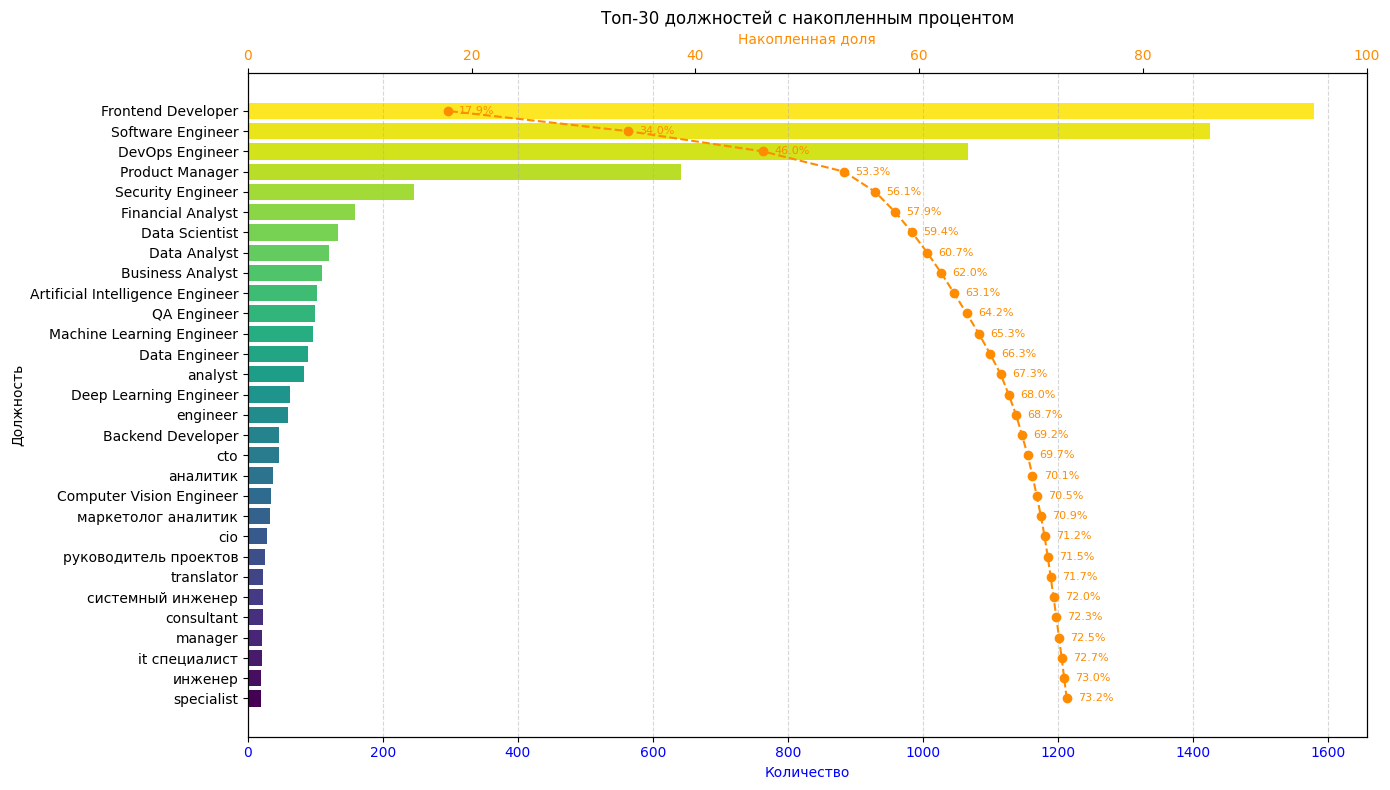

In [33]:
resume["experience_list"] = resume["title"].apply(
    lambda s: [t.strip() for t in str(s).split(",") if t.strip()]
)
exploded_titles = resume.explode("experience_list")
top_n = 30

plot_top_with_cumulative(
    series=exploded_titles["experience_list"],
    top_n=top_n,
    ylabel="Должность",
    title=f"Топ-{top_n} должностей с накопленным процентом",
)
resume.drop(columns=["experience_list"], inplace=True)

In [27]:
print(resume.sample(1)['experience'].tolist()[0])

Опыт работы 18 лет 10 месяцев
Июль 2021 — по настоящее время
4 года 9 месяцев
ООО "СПБДев"
spbdev.biz/
Информационные технологии, системная интеграция, интернет... Показать еще
Senior System Engineer / Junior(Middle) DevOps
Участие в различных проектах зарубежных и российских в качестве системного инженера или девопс специалиста.
Обслуживание информационных инфраструктур клиентов. Начиная от сопровождения on-premise кластеров VMware/Hyper-V/Xen, заканчивая разворачиванием и настройкой отдельных SAAS в облаках.
Настройка и отладка процессов CI/CD
Сопровождение проектов по миграции в/из облаков (Azure, AWS).
Декабрь 2020 — август 2021
9 месяцев
ООО "Бочкарёвский пивоваренный завод"
Заместитель руководителя службы ИТ по информационной безопасности
Построение ИТ инфраструктуры с учетом современных тенденций в области информационной безопасности.
Май 2016 — декабрь 2020
4 года 8 месяцев
ЗАО "СЭУС"
Главный специалист по ИТ
Организация работы ИТ отдела (6 человек): обеспечение работы ИТ инфра

In [34]:
resume.to_csv('total_resume_v1.csv', index=False)

На этом этапе сформируем **checkpoint_1** для последующей генерации данных в файле `gen_data.ipynb`.

**Вывод:**  
- Описания резюме содержат короткие и порой незаконченные фрагменты описания опыта работы, поэтому необходимо реконструировать контент кандидата, доработав исходный опыт работы.
- Также стоит заполнить записи с пустыми навыками явными указанными навыками, поскольку в некоторых резюме поля с навыками отсутствуют или заполнены неполностью.

### Очистка и нормализация (field: skills)

Используем данные этапа **checkpoint_2** из `get_data.ipynb`.   

Используем поле `synth_skills` чтобы заполнить пустые пропуски в поле key_skills.

Поскольку в колонке skills содержатся как hard skills, так и длинные описательные фразы (soft skills и обязанности), что мешает модели обучаться. Поэтому для стабильного обучения будем использовать только **конкретные инструменты, технологии и уникальные навыки**.

**Очистка и нормализация**   
В колонке skills часто встречаются **подробные пункты опыта работы** (“Analyzed and gathered business requirements…”). Подобные примеры **непоследовательные, не совсем технические** и плохо подходят в качестве токенов навыков. Некоторые резюме содержат **сотни токенов**, что создаёт шум.

Будем удалять навыки, которые:      
- **Слишком длинные** или содержат много слов;
- Заканчиваются **знаками препинания, как в предложениях**;
- Избавляемся от спец. символов;
- Содержат распространённые **глаголы ответственности** (“managed”, “implemented”, “maintained” и др.);
- Начинаются с **глаголов задач** (“identify”, “review”, “create”, “plan”, “test” и т.п.);
- Содержат языки на котором должен уметь/умеет разговаривать кандидат;

Также будем:    
- **Нормализовывать** аббревиатуры и варианты написания (например, *js -> JavaScript*, единообразное использование регистра).
- **Удалять дубликаты** навыков внутри одного резюме.

**Обработка выбросов**    
Резюме с чрезмерно длинными списками навыков исключаются, так как они:
- Выступают как **выбросы** при обучении.
- Вредят обучению семантической близости, увеличивая шум токенов.

В результате создадим поле *clean_skills*, который будет содержать **краткие, последовательные и готовые к обучению токены навыков**.

In [ ]:
resume = pd.read_csv('total_resume_v2.csv')

resume.dropna(subset=['key_skills'], inplace=True)

In [102]:
resume['key_skills'] = (
    resume['key_skills'].apply(lambda x: [s.strip() for s in x.split(';')] if isinstance(x, str) else x)
)
resume = resume[(resume['key_skills'] \
                       .apply(lambda x: [i for i in x if i !='']) \
                       .apply(len) == resume['key_skills_raw'] \
                       .apply(lambda x:  ast.literal_eval(x)).apply(len))]

In [240]:
resume.iloc[1]['experiences']

"['Разработка бэк-энд части веб-сервисов, парсеров и ботов. Развертывание dev-сред на ОС Linux. Проведение собеседований на позиции Python/fullstack разработчиков. Внедрение ежедневных дейли созвонов и Agile-практик для повышения эффективности команды. Введение code review для улучшения качества кодовой базы. Проектирование и разработка аналитической платформы для маркетплейсов с использованием стека Python, Django, DRF, FastAPI, React, Redis, S3. Определение архитектурных решений и выбор технологического стека для проектов.', 'Разработка бэк-энд части на Python Django и фронт-энд части на Django Templates/Vue JS. Проведение code review, оценочных сессий и утренних дейли созвонов. Разработка и запуск B2B enterprise маркетплейса для Schneider Electric с последующей оптимизацией его функциональности.', 'Разработка бэк-энд части веб-сервисов, парсеров и ботов. Развертывание dev-сред на ОС Linux. Участие в проектировании и реализации решений с акцентом на backend-компоненты.', 'Проектирова

In [242]:
print(resume.iloc[1]['experience'])

Work experience 6 years 4 months
March 2024 — currently
2 years 1 month
ООО "КодКрафт"
Moscow, code-craft.su
Ведущий разработчик fullstack
Разработка бэк-энд части веб-сервисов, разработка парсеров, разработка ботов. Развертывание dev сред на ОС Linux, проведение собеседований на должности python/fullstack разрабочиков
Добился на рабочем месте увеличения производительности команды за счет введения ежедневных дейли созвонов и Agile практик. Так же добился улучшения уровня кодовой базы за счет введения сode review.
Самым крупным проектом была аналитическая платформа для маркетплейсов. Была мною полностью спроектирована, разработана. Стек: Python, Django, DRF, FastAPI, React, Redis, S3
Так же на данном рабочем месте все проеты были спроектированы мной, решения по стеку технолгоий так же принимал я
March 2023 — march 2024
1 year 1 month
Агора
Moscow, /
Программист-разработчик
Разработка бек-энд части на Python Django, разработка фронт-энд части на Django Templates/Vue JS, проведение CR, пр

In [21]:
REMOVE_CHARS = r"[&%$*()]"
TECH_EXCEPTIONS = {"c++", "c#", "f#"}


def clean_sub_token(token: str) -> str:
    token = token.lower().strip()

    if token in EXCLUDE_SUB_TOKENS or token in TECH_EXCEPTIONS:
        return token

    token = BeautifulSoup(token, "html.parser").get_text().strip()
    token = re.sub(REPLACE_WITH_SPACE, ' ', token)
    token = re.sub(REMOVE_CHARS, ' ', token)
    token = token.replace('etc', '')

    token = re.sub(r'\d+', '', token)
    return token.strip()
    

def normalize_sub_skills(skills: list):
    normalized = []

    for skill in skills:
        if not isinstance(skill, str):
            continue

        sub_tokens = skill.split()
        cleaned_tokens = []

        for sub in sub_tokens:
            cleaned = clean_sub_token(sub)
            
            if cleaned: 
                cleaned_tokens.append(cleaned)

        if cleaned_tokens:
            final_token = " ".join(cleaned_tokens)
            normalized.append(final_token)

    return list(set(normalized))

In [20]:
EXCLUDE_SUB_TOKENS = {
    'a/b','i/o', 'b2b', 'b2c', 
    'j2ee','l1','l2','l3','l4',
    's3', 'c2s', 'ec2', 'c2c'
}

REMOVE_CHARS = r"[+&%$*().]"
REPLACE_WITH_SPACE = r"[/:]"


ACRONYMS = [
    "SQL",
    "IT",
    "UI",
    "UX",
    "API",
    "ETL",
    "AWS",
    "IOS",
    "XML",
    "HTML",
    "CSS",
    "PHP",
    "ML", 
    "CV", 
    "RL",
    "LLM", 
    "RAG", 
    "MLOPS", 
    "EDA",
    "DL", 
    "CNN", 
    "RNN", 
    "LSTM", 
    "GRU",
    "GAN", 
    "VAE",
    "ООП"
]

SPECIAL_MAP = {
    "js": "javascript",
    "ts": "typescript",
    "py": "python",
    "ms": "microsoft",
    "go": "golang",
    "node.js": "nodejs",
    "react.js": "react",
    "reactjs": "react",
    "node.js": "nodejs",
    "angular.js": "angularjs",
    "restframework": "react",
    "django restframework": "django",
    "vue.js": "vue",
    "vue 3": "vue",
    "next.js": "nextjs",
    "nuxt.js": "nuxtjs",
    "php5": "php",
    "etl/elt": "etl elt",  
    "powerbi": "power bi",

    "ml": "machine learning",
    "dl": "deep learning",
    "ai": "artificial intelligence",
    "genai": "generative ai",
    "cv": "computer vision",
    "nlp": "natural language processing",
    "rl": "reinforcement learning",
    "rag": "retrieval augmented generation",
    "asr": "automatic speech recognition",
    "tts": "text to speech",
    "gan": "generative adversarial network",
    "vae": "variational autoencoder",
    

    "ds": "data scientist",
    "da": "data analyst",
    "de": "data engineer",
    "mle": "machine learning engineer",
    "ai eng": "ai engineer",
    "ml eng": "machine learning engineer",
    "bi": "business intelligence",
    "ba": "business analyst",

    "tf": "tensorflow",
    "pt": "pytorch",
    "sklearn": "scikit-learn",
    "xgb": "xgboost",
    "lgbm": "lightgbm",
    "catboost": "catboost",
    "hf": "huggingface",
    "spacy": "spacy",
    "nltk": "nltk",

    "spark": "apache spark",
    "hdfs": "hadoop distributed file system",
    "hadoop": "apache hadoop",
    "kafka": "apache kafka",
    "airflow": "apache airflow",
    "dbt": "data build tool",
    "bs4": "beautifulsoup",

    "aws": "amazon web services",
    "gcp": "google cloud platform",
    "azure": "microsoft azure",
    "s3": "amazon s3",
    "ec2": "amazon ec2",

    "k8s": "kubernetes",
    "mlops": "machine learning operations",
    "devops": "development operations",
    "ci": "continuous integration",
    "cd": "continuous deployment",
    "ci/cd": "continuous integration continuous deployment",
    "ci-cd": "continuous integration continuous deployment",
    "cicd": "continuous integration continuous deployment",
    "iac": "infrastructure as code",
    "terraform": "terraform",
    "ansible": "ansible",

    "postgres": "postgresql",
    "mongo": "mongodb",
    "redis": "redis",
    "mysql": "mysql",
    "mssql": "microsoft sql server",
    "nosql": "non relational database",

    "pbi": "power bi",
    "tableau": "tableau",
    "qlik": "qlikview",
    "css3": "css",
    "html5": "html",

    "agile": "agile methodology",
    "scrum": "scrum framework",
    "kanban": "kanban method",
    "jira": "atlassian jira",
}


EXPERIENCE_VERBS = [
    "managed",
    "maintained",
    "responsible",
    "supported",
    "provided",
    "ensured",
    "analyzed",
    "resolved",
    "troubleshot",
    "troubleshooting",
    "developed",
    "installed",
    "configured",
    "handled",
    "engaged",
    "drove",
    "communicated",
    "explained",
    "assumed",
    "acted",
    "diagnosed",
    "and",
]


START_VERBS = [
    "identify",
    "product testing",
    "pspice",
    "renewable energy",
    "simapro",
    "simpowersystems",
    "turbo pascal",
    "assembler",
    "simulink",
    "adobe photoshop",
    "autocad",
    "electrical",
    "labview",
    "review",
    "gather",
    "create",
    "document",
    "perform",
    "schedule",
    "plan",
    "participate",
    "execute",
    "approve",
    "approved",
    "confirmed",
    "tracked",
    "controlled",
    "managed",
    "defined",
    "formulated",
    "assembled",
    "bachelor's degree",
    "attention to detail",
    "coordinated",
    "follow",
    "турецкий",
    "хинди",
    "followed",
    "uploaded",
    "suggested",
    "verified",
    "перевод",
    "английский",
    "персидский",
    "русский",
    "иврит",
    "немецкий",
    "узбекский",
    "казахский",
    "белорусский",
    "nan",
    "finnish",
    "belarusian",
    "корейский",
    "армянский",
    "румынский",
    "кыргызский",
    "португальский",
    "spanish",
    "russian",
    "azerbaijani", 
    "bulgarian", 
    "burmese", 
    "portuguese", 
    "norwegian", 
    "dutch", 
    "uzbek",
    "english",
    "kyrgyz",
    "украинский",
    "финский",
    "испанский",
    "грузинский",
    "азербайджанский",
    "polish",
    "датский",
    "португальский", 
    "грамотная",
    "латышский",
    "японский",
    "hebrew",
    "turkish",
    "болгарский", 
    "serbian", "armenian",
    "estonian", "latin", "датский",  
    "afrikaans", "bengali", "catalan", 
    "lithuanian", "georgian", 
    "шведский", "greek", "чувашский",
    "тагальский", "норвежский", 
    "туркменский", "голландский", 
    "windows", "словенский", 
    "тувинский", "turkmen",    
    'kurdish', 
    "вьетнамский",
    "урду",
    "bengali",
    "російська",
    'persian',
    'latvian', 
    'hindi', 
    'латинский', 
    'arabic',
    "исполнение",
    "арабский",
    "татарский",
    "сербский",
    "таджикский",
    "французский",
    "german",
    "kendoui",
    "итальянский",
    "kazakh",
    "french",
    "croatian",
    "ukrainian",
    "польский",
    "italian",
    "китайский",
    "чешский",
    "korean",
    "chinese",
    "финансовые",
    "communication skills",
    "problemsolving",
    "problem solving",
    "communication"
]

verb_pattern = re.compile(r"\b(" + "|".join(EXPERIENCE_VERBS) + r")\b", re.IGNORECASE)

def normalize_skill(s):
    if s is None or (isinstance(s, float) and math.isnan(s)):
        return ""

    s = str(s).strip()
    if not s:
        return ""

    s_lower = s.lower()

    if s_lower in SPECIAL_MAP:
        return SPECIAL_MAP[s_lower]
    
    return s_lower


def is_valid_skill(s):
    if not s:
        return False
        
    s_strip = s.strip()
    words = s_strip.split()

    if len(words) > 6:
        return False
        
    if len(s_strip) > 80:
        return False

    first_word = words[0].lower()
    if first_word in START_VERBS:
        return False

    if s_strip[-1] in ".!?":
        return False

    if verb_pattern.search(s_strip) and len(words) > 5:
        return False

    return True


def clean_skill_list(skills_list):
    cleaned = []
    seen = set()

    for raw in skills_list:
        norm = normalize_skill(raw)
        if is_valid_skill(norm):
            if norm not in seen:
                seen.add(norm)
                cleaned.append(norm)

    return cleaned



def clean_sub_token(token: str) -> str:
    token = token.lower().strip()

    if token in EXCLUDE_SUB_TOKENS:
        return token

    token = BeautifulSoup(token, "html.parser").get_text().strip()
    token = re.sub(REPLACE_WITH_SPACE, ' ', token)
    token = re.sub(REMOVE_CHARS, ' ', token)
    token = token.replace('etc', '')

    token = re.sub(r'\d+', '', token)
    return token.strip()


def normalize_sub_skills(skills: list):
    normalized = []

    for skill in skills:
        if not isinstance(skill, str):
            continue

        sub_tokens = skill.split()
        cleaned_tokens = []

        for sub in sub_tokens:
            cleaned = clean_sub_token(sub)
            
            if cleaned: 
                cleaned_tokens.append(cleaned)

        if cleaned_tokens:
            final_token = " ".join(cleaned_tokens)
            normalized.append(final_token)

    return list(set(normalized))



def remove_special_symp(skills_list: list):
    special_chars = r'[!@#$%^&*()_+=\[\]{};:\'",<>?\\|]'
    cleaned = []
    
    for skill in skills_list:        
        s = re.sub(special_chars, '', skill)
        s = s.strip()
        
        if s:
            cleaned.append(s)
    return cleaned

In [106]:
resume["clean_skills"] = resume["key_skills"].apply(clean_skill_list)
resume["clean_skills"] = resume["clean_skills"].apply(normalize_sub_skills)
resume["clean_skills"] = resume["clean_skills"].apply(remove_special_symp)

In [107]:
# переводим list в string 
def to_string(data):
    if isinstance(data, str):
        try:
            data = ast.literal_eval(data)
            return " ".join(data)
        except:
            return data
    return


resume['string_experiences'] = resume['experiences'].apply(to_string)

### Очистка и агрегация доменов в единую категорию (должности)
- Будет выполнена агрегация должностей, относящихся к смежным доменам, в случае если количество примеров для каждой из них недостаточно.

- Должности с неявно заданными ролями (например, Data Scientist), охватывающие широкий спектр задач и специализаций, будут перераспределены в более конкретные и близкие категории. Определение наиболее подходящей категории осуществляется на основе семантической близости между описаниями резюме и эталонными категориями, вычисляемой с использованием модели multilingual-e5-large-instruct.

- Все оставшиеся должности, не относящиеся к IT-сфере и не попадающие под правила агрегации, будут удалены из датасета. Также будут исключены категории с малым количеством примеров.

In [108]:
# Группируем с 'Backend Developer'
mapping = {
    'Golang Developer': 'Backend Developer',    
    'Java Developer': 'Backend Developer',
}

resume['title'] = resume['title'].apply(lambda x: x.strip() if isinstance(x, str) else None)
resume['title'] = resume['title'].replace(mapping)

In [109]:
# Группируем с 'Deep Learning Engineer'

mapping = {
    'Computer Vision Engineer': 'Deep Learning Engineer',
}

resume['title'] = resume['title'].replace(mapping)

In [110]:
# Группируем с 'Security Engineer'

mapping = {
    'Security Analyst': 'Security Engineer',
}

resume['title'] = resume['title'].replace(mapping)

In [111]:
# Группируем с 'Business Analyst'

mapping = {
    'System Analyst': 'Data Analyst',
    'Business Analyst': 'Data Analyst'
}


resume['title'] = resume['title'].replace(mapping)

### Разбиваем на подкатегории должности с неявной ролью

In [112]:
def get_full_text(df, col_title, col_description, col_skills):
    return (
        "Описание: " +
        df[col_description].fillna('') 
        +
        " Навыки: " + df[col_skills].apply(lambda x: ', '.join(x) if isinstance(x, tuple) else '')
    )


def average_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]


def split_corpus(df, titles, col_title="title", category=None):
    anchor_df = df[df[col_title].isin(titles)].copy()

    if category is None:
        assigned_df = df.iloc[0:0].copy()
    elif isinstance(category, (list, tuple, set)):
        assigned_df = df[df[col_title].isin(category)].copy()
    else:
        assigned_df = df[df[col_title] == category].copy()

    return anchor_df, assigned_df


def load_model_tokenizer(model_name="intfloat/multilingual-e5-large", device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    model.to(device)
    return tokenizer, model


def encode_texts(texts, prefix, batch_size=32, max_length=512, device="cuda"):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            if prefix:
                batch = [f"{prefix}: {text}" for text in batch]
            else:
                batch = [text for text in batch]

            batch_dict = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**batch_dict)
            embeddings = average_pool(outputs.last_hidden_state, batch_dict['attention_mask'])
            embeddings = F.normalize(embeddings, p=2, dim=1)

            all_embeddings.append(embeddings)
    return torch.cat(all_embeddings, dim=0)


def fit_embeddings(anchor_df, col_title, col_description, col_skills):
    anchor_texts = get_full_text(anchor_df, col_title=col_title, col_description=col_description, col_skills=col_skills).tolist()
    anchor_embeddings = encode_texts(
        anchor_texts,
        prefix="passage"
    )
    return anchor_embeddings
    

def assign_category_to_merge_e5(
    merge_df,
    anchor_embeddings,
    anchor_labels,
    col_title,
    col_description,
    col_skills,
    top_k=30
):

    texts = get_full_text(merge_df, col_title=col_title, col_description=col_description, col_skills=col_skills).tolist()

    merge_embeddings = encode_texts(
        texts,
        prefix='query'
    )
    sim_matrix = merge_embeddings @ anchor_embeddings.T

    new_categories = []
    for i in range(sim_matrix.shape[0]):

        k = min(top_k, len(anchor_labels))
        top_indices = sim_matrix[i].topk(k).indices.tolist()
        top_labels = [anchor_labels[idx] for idx in top_indices]

        category = Counter(top_labels).most_common(1)[0][0]
        new_categories.append(category)

    merge_df = merge_df.copy()
    merge_df[col_title] = new_categories

    return merge_df



def assign_categories_from_merge(
    df_resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
):

    merge_subset = merge_df[on_columns + [col_title]].copy()

    df_merged = df_resume.merge(
        merge_subset,
        how='left',
        on=on_columns,
        suffixes=('', '_new')
    )

    df_merged[col_title] = df_merged[f'{col_title}_new'].combine_first(df_merged[col_title])
    df_merged.drop(columns=[f'{col_title}_new'], inplace=True)
    return df_merged

In [113]:
tokenizer, model = load_model_tokenizer()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Распределяем неявные должности между типа должностей о аналитике.

In [114]:
titles = [
    'Financial Analyst',
    'Data Analyst'
]

anchor_df, assigned_df = split_corpus(
    resume,
    titles,
    'title',
    ['аналитик','analyst','маркетолог аналитик','маркетолог, аналитик','data analytics',
    "руководитель аналитики, технический лидер, data architect", "аналитик machine learning",
    "аналитик, тест лид, руководитель нагрузочного тестирования",
    "аналитик, it специалист, информационная безопасность",
    'data analysis', 'аналитика данных','analyst']
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title='title', col_skills='clean_skills', col_description='string_experiences')

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_skills='clean_skills',
    col_description='string_experiences',
    top_k=50
)

resume = assign_categories_from_merge(
    resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
)

Теперь распределяем данные должности `Software Engineer`.

In [115]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer'
]

anchor_df, assigned_df = split_corpus(
    resume,
    titles,
    'title',
    ['Software Engineer',"data sciеntist","software testing engineer"]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title='title', col_skills='clean_skills', col_description='string_experiences')

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_skills='clean_skills',
    col_description='string_experiences',
    top_k=30
)

resume = assign_categories_from_merge(
    resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
)

Теперь распределяем данные должности `Data Scientist`.

In [116]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer'
]

anchor_df, assigned_df = split_corpus(
    resume,
    titles,
    'title',
    [
    'Data Scientist', 
     "специалист по машинному обучению и обработке естественного языка",
    "machine learning team", "data sciеntist",
     "machine learning", "machine learning, deep learning",
    
    ]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title='title', col_skills='clean_skills', col_description='string_experiences')

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_skills='clean_skills',
    col_description='string_experiences',
    top_k=30
)

resume = assign_categories_from_merge(
    resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
)

Теперь распределяем данные должности `Machine Learning Engineer`.

In [117]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer',
]

anchor_df, assigned_df = split_corpus(
    resume,
    titles,
    'title',
    ['Machine Learning Engineer']
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title='title', col_skills='clean_skills', col_description='string_experiences')

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_skills='clean_skills',
    col_description='string_experiences',
    top_k=30
)

resume = assign_categories_from_merge(
    resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
)

Теперь распределяем данные должности `Python Developer`.

In [118]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer',
    'Backend Developer',
]

anchor_df, assigned_df = split_corpus(
    resume,
    titles,
    'title',
    ['Python Developer',  "deops инженер"]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title='title', col_skills='clean_skills', col_description='string_experiences')

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_skills='clean_skills',
    col_description='string_experiences',
    top_k=30
)

resume = assign_categories_from_merge(
    resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
)

Группируем схожие должности `Data Engineer`.

In [119]:
titles = [
    'Data Engineer'
]

anchor_df, assigned_df = split_corpus(
    resume,
    titles,
    'title',
    ["дата инженер", "data architect"]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title='title', col_skills='clean_skills', col_description='string_experiences')

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_skills='clean_skills',
    col_description='string_experiences',
    top_k=30
)

resume = assign_categories_from_merge(
    resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
)

### Визуализируем полученные категории (должности) после группировки

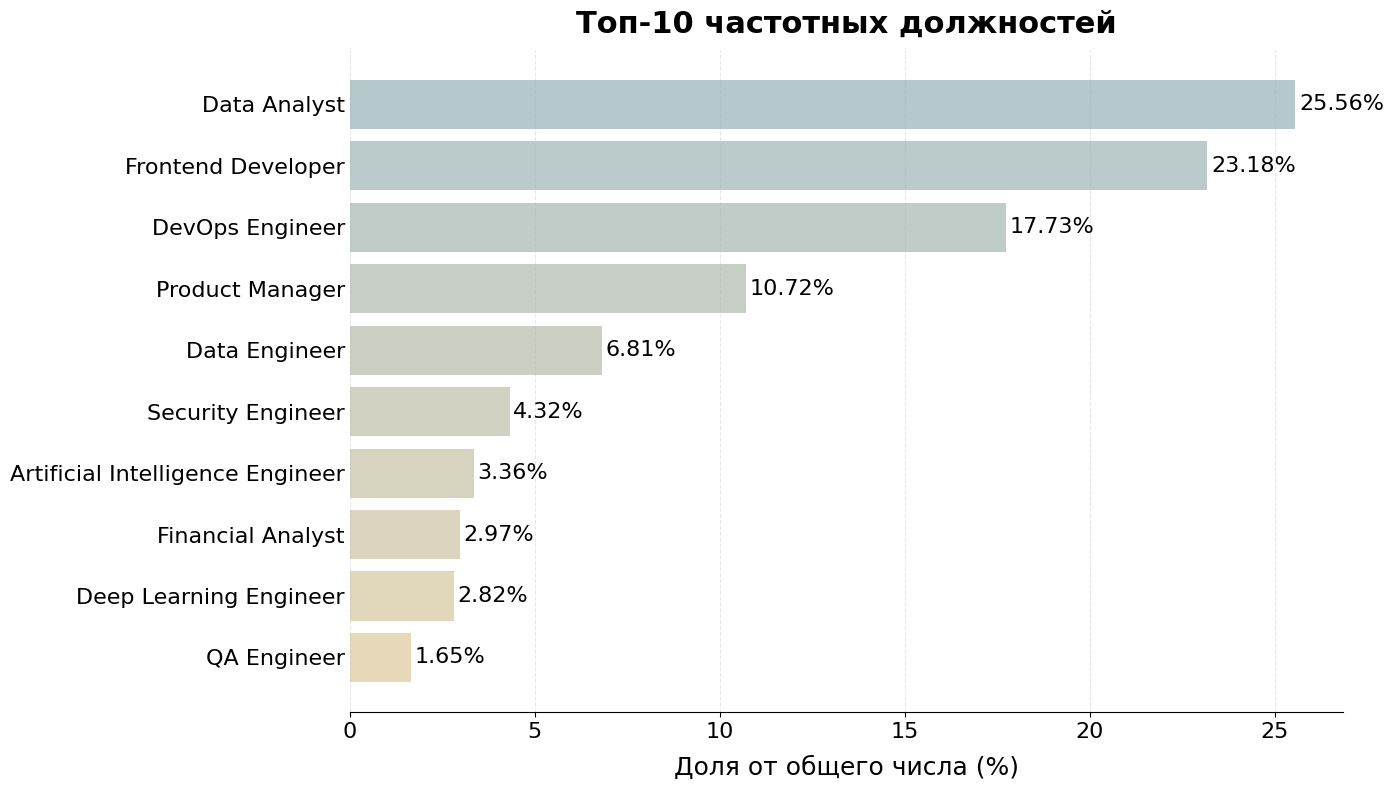

In [ ]:
def plot_top_with_percentage(series, top_n=30, ylabel="Категория", title="Распределение (%)"):

    counts = series.value_counts().head(top_n)
    total = len(series)
    percentages = (counts / total * 100).round(2)
    percentages = percentages.sort_values()

    fig, ax = plt.subplots(figsize=(14, 8))

    cmap = LinearSegmentedColormap.from_list(
        "soft_blue_sand", ["#F5DEB3", "#AEC6CF"]
    )
    colors = cmap(np.linspace(0.2, 0.9, len(percentages)))

    ax.barh(
        percentages.index,
        percentages.values,
        color=colors,
        edgecolor="none"
    )

    ax.set_xlabel("Доля от общего числа (%)", fontsize=18, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.set_title(title, fontsize=22, fontweight="bold", pad=12)

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.tick_params(axis="y", labelsize=16, length=0)
    ax.tick_params(axis="x", labelsize=16)

    for i, (val, name) in enumerate(zip(percentages.values, percentages.index)):
        ax.text(val + 0.1, i, f"{val:.2f}%", va="center", fontsize=16)

    plt.tight_layout()
    plt.show()


top_n = 10
plot_top_with_percentage(
    series=resume['title'],
    top_n=top_n,
    ylabel="",
    title=f"Топ-{top_n} частотных должностей",
)

Отберем все основные должности.

In [128]:
title_counts = resume['title'].value_counts()
valid_titles = title_counts[title_counts >= 50].index
resume_filtered = resume[resume['title'].isin(valid_titles)].copy()

In [130]:
resume_filtered.to_csv('total_resume_v3.csv', index=False)

На этом этапе сформируем **checkpoint_3** для последующей генерации данных в файле `gen_data.ipynb`.

## **Обработка (вакансий)**

Аналогичные этапе проведем для вакансий.

In [ ]:
vacancy = pd.read_csv('total_vacancy.csv')

In [ ]:
# избавимся от пустых значений и дубликатов
vacancy.dropna(subset=['description'], inplace=True)
vacancy.drop_duplicates(subset=['description'], inplace=True)
vacancy.drop_duplicates(subset=['vacancy_id'], inplace=True)

In [ ]:
print(f'Общий размер корпуса: {vacancy.shape}')
vacancy.head()

In [878]:
vacancy.sample(1)['description'].tolist()[0]

'Вакансия: Таргетолог Meta (Instagram/Facebook Ads)   О компании: DGTeam Marketing Agency работает в сфере интернет-маркетинга и лидогенерации. • $100 000+ рекламный бюджет в месяц • Работаем с 2020 года • Основное направление — клиники красоты/стоматологии   Обязанности: ✅ Запуск и оптимизация рекламных кампаний в Instagram и Facebook ✅ Написание продающих текстов для объявлений ✅ Составление технического задания для дизайнера ✅ Участие в разработке стратегии продвижения проектов ✅ Контроль за метриками и достижением KPI ✅ Ведение отчетности и участие в командных созвонах   Кого мы ищем: Нам нужен современный Meta ads специалист, который понимает маркетинг, стратегию, аудитории и креативы. С уверенными навыками работы в AI, который ускоряет тесты и производство гипотез   Чем ты будешь заниматься: • Запускать и вести рекламные кампании в Meta ads под лидогенерацию для клиник/бьюти-услуг. • Делать тесты, быстро проверять гипотезы. • Анализировать результаты и улучшать KPI • Формировать 

**Вывод:**

- необходимо удалить специальные символы;
- следует извлечь из текста вакансии разделы с обязанностями и требованиями, чтобы устранить неинформативные данные;
- необходимо выделить явно указанные навыки, поскольку в некоторых вакансиях поля с навыками отсутствуют или заполнены неполностью.

### Очистка и нормализация (field: name)

На этом этапе поле `name` в вакансии приводится к единому и компактному формату, подходящему для сопоставления и векторизации.

В процессе:
- Поле нормализуется в список названий должностей.
- Каждое название очищается: удаляется пунктуация, раскрываются сокращения, нормализуется регистр.

In [ ]:
# Очистим описания корпуса данных от спец-символов и другой шумной информации.

vacancy['description'] = vacancy['description'].apply(clean_text_comprehensive)

In [ ]:
# нормализуем названия должности

vacancy["title"] = vacancy["name"] \
    .apply(lambda x: re.sub(LEVEL_WORDS, "", x.lower())) \
    .apply(normalize_role)

vacancy["title"] = vacancy["title"].apply(lambda x: x.strip() if isinstance(x, str) else x)

In [882]:
vacancy.to_csv('total_vacancy_v1.csv', index=False)

На данном этапе сформируем для **вакансий** набор данных **checkpoint_1**, который будет использован на следующем шаге для генерации данных в файле `gen_data.ipynb`.

### Очистка и нормализация (field: key_skills)

На этом этапе поле `key_skills` в вакансии приводится к единому и компактному формату, подходящему для сопоставления и векторизации.

В процессе:
- Поле нормализуется в список названий должностей.
- Каждое название очищается: удаляется пунктуация, раскрываются сокращения, нормализуется регистр.
   
  
  
  
Будем использовать данные с **checkpoint_2** для раздела **вакансий**, который был сформирован из файла `gen_data.ipynb`.

In [131]:
vacancy = pd.read_csv('total_vacancy_v2.csv')

In [ ]:
# заполним пустые навыки навыками, полученные из описания
# + нормализуем навыки



def split_job_skill_string(s):
    if not isinstance(s, str):
        return []

    for sep in [";", "."]:
        s = s.replace(sep, ",")

    return [x.strip() for x in s.split(",") if x.strip()]



vacancy.rename(columns={'skills':'synth_skills'}, inplace=True)

vacancy['job_skills'] = vacancy['key_skills'].fillna(vacancy['skills']).fillna('')
vacancy['job_skills'] = vacancy['job_skills'].apply(split_job_skill_string)

vacancy["clean_skills_tuple"] = vacancy["job_skills"].apply(
    lambda x: tuple(sorted(x))
)

vacancy["job_skills_clean"] = vacancy['clean_skills_tuple'].apply(clean_skill_list)
vacancy["job_skills_clean"] = vacancy["job_skills_clean"].apply(normalize_sub_skills)
vacancy["job_skills_clean"] = vacancy["job_skills_clean"].apply(remove_special_symp)

### Агрегируем названия должностей

In [139]:
# Группируем с 'Backend Developer'
mapping = {
    'Golang Developer': 'Backend Developer',    
    'Java Developer': 'Backend Developer',
}

vacancy['title'] = vacancy['title'].apply(lambda x: x.strip() if isinstance(x, str) else None)
vacancy['title'] = vacancy['title'].replace(mapping)

In [140]:
# Группируем с 'Deep Learning Engineer'

mapping = {
    'Computer Vision Engineer': 'Deep Learning Engineer',
}

vacancy['title'] = vacancy['title'].replace(mapping)

In [141]:
# Группируем с 'Security Engineer'

mapping = {
    'Security Analyst': 'Security Engineer',
}

vacancy['title'] = vacancy['title'].replace(mapping)

In [142]:
# Группируем с 'Data Analyst'

mapping = {
    'System Analyst': 'Data Analyst',
    'Business Analyst': 'Data Analyst'
}

vacancy['title'] = vacancy['title'].replace(mapping)

### Разбиваем на подкатегории должности с неявной ролью

In [145]:
def get_full_text(df, col_title, col_resp, col_req, col_skills):
    return (
        "Описание: " +
        df[col_resp].fillna('') 
        +
        df[col_req].fillna('') 
        +
        " Навыки: " + df[col_skills].apply(lambda x: ', '.join(x) if isinstance(x, tuple) else '')
    )


def average_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]


def split_corpus(df, titles, col_title="title", category=None):
    anchor_df = df[df[col_title].isin(titles)].copy()

    if category is None:
        assigned_df = df.iloc[0:0].copy()
    elif isinstance(category, (list, tuple, set)):
        assigned_df = df[df[col_title].isin(category)].copy()
    else:
        assigned_df = df[df[col_title] == category].copy()

    return anchor_df, assigned_df


def load_model_tokenizer(model_name="intfloat/multilingual-e5-large", device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()
    model.to(device)
    return tokenizer, model


def encode_texts(texts, prefix, batch_size=32, max_length=512, device="cuda"):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            if prefix:
                batch = [f"{prefix}: {text}" for text in batch]
            else:
                batch = [text for text in batch]

            batch_dict = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(device)

            outputs = model(**batch_dict)
            embeddings = average_pool(outputs.last_hidden_state, batch_dict['attention_mask'])
            embeddings = F.normalize(embeddings, p=2, dim=1)

            all_embeddings.append(embeddings)
    return torch.cat(all_embeddings, dim=0)


def fit_embeddings(anchor_df, col_title, col_resp, col_req, col_skills):
    anchor_texts = get_full_text(anchor_df, col_title=col_title, col_resp=col_resp, col_req=col_req, col_skills=col_skills).tolist()
    anchor_embeddings = encode_texts(
        anchor_texts,
        prefix="passage"
    )
    return anchor_embeddings
    

def assign_category_to_merge_e5(
    merge_df,
    anchor_embeddings,
    anchor_labels,
    col_title,
    col_resp,
    col_req,
    col_skills,
    top_k=30
):

    texts = get_full_text(merge_df, col_title=col_title, col_resp=col_resp, col_req=col_req, col_skills=col_skills).tolist()

    merge_embeddings = encode_texts(
        texts,
        prefix='query'
    )
    sim_matrix = merge_embeddings @ anchor_embeddings.T

    new_categories = []
    for i in range(sim_matrix.shape[0]):

        k = min(top_k, len(anchor_labels))
        top_indices = sim_matrix[i].topk(k).indices.tolist()
        top_labels = [anchor_labels[idx] for idx in top_indices]

        category = Counter(top_labels).most_common(1)[0][0]
        new_categories.append(category)

    merge_df = merge_df.copy()
    merge_df[col_title] = new_categories

    return merge_df



def assign_categories_from_merge(
    df_resume,
    merge_df,
    on_columns=['resume_id'],
    col_title='title'
):

    merge_subset = merge_df[on_columns + [col_title]].copy()

    df_merged = df_resume.merge(
        merge_subset,
        how='left',
        on=on_columns,
        suffixes=('', '_new')
    )

    df_merged[col_title] = df_merged[f'{col_title}_new'].combine_first(df_merged[col_title])
    df_merged.drop(columns=[f'{col_title}_new'], inplace=True)
    return df_merged

In [49]:
tokenizer, model = load_model_tokenizer()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Распределяем неявные должности между типа должностей о аналитике.

In [146]:
titles = [
    'Financial Analyst',
    'Data Analyst'
]

anchor_df, assigned_df = split_corpus(
    vacancy,
    titles,
    'title',
    [        
"аналитик бизнес-процессов", "аналитик 1с erp", "marketing analyst", "fullstack аналитик", "аналитик по продажам", 
"риск-аналитик", "аналитик 1с (регламентированный учет)", "аналитик 1с:erp", "аналитик отдела маркетинга",
"экономист - аналитик", "специалист по ценообразованию", "риск-аналитик", "продуктовый аналитик ()",'аналитик казначейства',
"процессный аналитик", "риск - аналитик", "fullstack аналитик (b2g)", "руководитель направления аналитики",
"специалист-аналитик", "бизнес - аналитик 1с", "антифрод-аналитик", "аналитик по работе с маркетплейсами",'специалист (аналитик)',
"операционный аналитик", "специалист-аналитик", "аналитик 1с зуп", "дата-аналитик", "бизнес - аналитик",
"web analyst", "инженер-аналитик", "analyst", "аналитик коммерческого отдела", "аналитик баз данных",
"аналитик soc", "аналитик 1с (ученик)", "аналитик/медиа-аналитик", 'head of analytics', "аналитик 1с: erp",
"младший аналитик 1с", "главный аналитик", 'аналитик рынка', 'начинающий аналитик', 'финансовый менеджер (аналитик)',
'web-аналитик', 'аналитик-исследователь', 'аналитик / медиа-аналитик', 'аналитик / консультант 1с',
'специалист отдела аналитики',"full-stack аналитик", 'аналитик в отдел кредитования (мсб)', 'ml-аналитик',
'аналитик (планирование и прогнозирование)', 'финансист-аналитик', 'финансист-аналитик','аналитик ()',
'аналитик в команду данные fair pricing', 'аналитик dlp', 'главный специалист-аналитик','аналитик (трансформация процессов финансовой функции)',
"аналитик dwh/bi", 'аналитик 1с erp (оперативный контур)', '-аналитик','аналитик 1с / методолог 1с',
'аналитик продаж со знанием sql','аналитик (excel)',
'1с аналитик','аналитик (отдел мониторинга дорожно-транспортной обстановки)','аналитик 1с (финансовый контур)','analytics engineer (dwh)',
'аналитик-статист', 'аналитик (сэд)','аналитик it', "аналитик клиентского опыта", "аналитик / специалист по управлению товарными запасами", "аналитик производственных данных",
'младший аналитик ( analyst)','data full-stack аналитик','analytics engineer','риск аналитик', 'аналитик 1с (честный знак)',
"аналитик статистических данных", "аналитик по стратегии в одноклассники / дата-аналитик", "аналитик (девелопмент)",
"аналитик по направлению апк",'аналитик качества данных','аналитик dwh ()', "anti-fraud analyst", "аналитик fullstack",
"/ + аналитик fullstack (бизнес + системный)", "младший аналитик 1с / младший консультант 1с",
'аналитик по работе с маркетплейсами (ozon, wildberries)','руководитель команды аналитики','сетевой инженер-аналитик / network analyst engineer',
'аналитик (инвестиции)', 'исследователь данных','аналитик (jaquar, uzbekistan)', 'аналитик-маркетолог (b2b)',
'аналитик по прогнозированию','младший бэк-аналитик (маркетплейсы / excel)','специалист сектора антифрод-аналитики','дата аналитик (поиск)',
"антифрод - аналитик", "аналитик по исследованиям (финтех)",'продуктовый аналитик/дата аналитик (транспорт)',
"аналитик отдела bigdata","аналитик (выявление и анализ сомнительных операций)", "ml аналитик",
"тимлид маркетинговой аналитики", "cистемный аналитик", 'аналитик по отчетности', "аналитик-","аналитик маркетплейса ozon", 'дата аналитик', 'аналитик (ценообразование, товарная аналитика)',
'аналитик в отдел маркетинга', 'аналитик 1с (erp)',"аналитик по исследованию рынка",'аналитик информационных систем',
"руководитель отдела аналитики и ценообразования", "финансовый менеджер - аналитик", 'аналитик / экономист', 'портфельный аналитик (риск-аналитик)','специалист по работе с excel (аналитик)',
'аналитик excel', 'fullstack (бизнес/системный) аналитик продуктовой команды', "аналитик 1с (зуп)", "стажёр-аналитик 1с", 'аналитик / эконометрист',
'аналитик в команду gigachat (b2bank)', 'ai аналитик','digital-аналитик','аналитик','финансовый менеджер',
'аналитик 1с','продуктовый аналитик', 'маркетолог-аналитик','экономист-аналитик',"аналитик dwh", "аналитик", "младший аналитик", "руководитель отдела аналитики", "1c analyst",
"fullstack-аналитик", "веб-аналитик", "аналитик по ценообразованию", "digital-аналитик", 'аналитик (рц)', 'ai аналитик', 'data-analyst', 'аналитик 1с ()', 'аналитик (bitrix24, b2b)'
    ]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title="title", col_req='requirements', col_resp='responsibilities', col_skills="job_skills_clean")

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_resp='responsibilities',
    col_req='requirements',
    col_skills="job_skills_clean", 
    top_k=30
)

vacancy = assign_categories_from_merge(
    vacancy,
    merge_df,
    on_columns=['vacancy_id'],
    col_title='title'
)

Теперь распределяем данные должности `Software Engineer`.

In [147]:
titles = [
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer',
    'DevOps Engineer',
    'Security Engineer',
    'QA Engineer',
    'Backend Developer',
]

anchor_df, assigned_df = split_corpus(
    vacancy,
    titles,
    'title',
    ['Software Engineer',
     "software testing engineer",
     "team  команды разработки", "руководитель группы разработки (team )",
    ".net engineer (sap)", "it-специалист", 'it engineer', 'php trainee',
    'руководитель команды разработки /  c++', "product marketing manager / продуктовый маркетолог",

    ]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title="title", col_req='requirements', col_resp='responsibilities', col_skills="job_skills_clean")

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_resp='responsibilities',
    col_req='requirements',
    col_skills="job_skills_clean", 
    top_k=30
)

vacancy = assign_categories_from_merge(
    vacancy,
    merge_df,
    on_columns=['vacancy_id'],
    col_title='title'
)

Теперь распределяем данные должности `Data Scientist`.

In [148]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer'
]


anchor_df, assigned_df = split_corpus(
    vacancy,
    titles,
    'title',
    [
'Data Scientist',
'специалист по нейросетям', "ai инженер", 'ai engineering', "ai-тренер в области программирования",
'nlp engineer (gigaсhat)', 'ml team  (kyc / id verification / biometrics)', 'nlp engineer (gigachat pretrain)',
'data architect', 'инженер (data/etl)', 'ml - инженер', "it специалист", 'сервисный инженер', 'архитектор больших данных',
"ml team", 'дата инженер', 'архитектор ml/ ai', 'fullstack в genai', 'ai-тренер для обучения alice ai',
'ai prompt & portfolio engineer intern (ai software)',
"ml-engineer", 'ml/ai инженер', 'руководитель ml команды "rec. system"','dsp-инженер', "mle специалист (цент практического ии)",
"ml-engineer (gigachat data alignment)", "executive it recruiter (с++, ml)", 'rag-engineer (mws ai)', "genai engineer",
"менеджер по внедрению искусственного интеллекта (ai)","ml","специалист по ml",
"ml/ai code generation engineer (asc ai fabrique)",'ml-engineer tts gigachat', 'компьютерное зрение, машинное обучение, ml, vc',
'риск-менеджер (валидация ml)', "инженер по техническому зрению (3d vision)",
"prompt-инженер", "nlp engineer (gigachat pretrain data)", "nlp engineer", "ai-тренер (gigachat)", 'nlp engineer (команда gigachat pretrain)',
'head of ai', '/ nlp/plp researcher (gigacode r&d)', "ai", 'специалист по искусственному интеллекту','инженер nlp/plp',
"team  / технический руководитель в digital-агентство", "специалист по разработке нейронных сетей", 'nlp инженер в gigachat alignment',
'системный архитектор ai/ml', 'ai team', 'специалист по оптимизации и автоматизации бизнес-процессов', 'директор по искусственному интеллекту (chief ai officer, caio)',
'dl-инженер', 'специалист по параллельным вычислениям на gpu/npu', 'ai research & automation engineer (tech researcher)',
'genai production engineer', "младший  специалист по разработке нейронных сетей", "руководитель направления (речевые технологии и синтез речи)",
"team  по разработке нейронных сетей", 'ml специалист', "инженер по машинному обучению и анализу данных", "ml - инженер (скан)",
"руководитель команды ml, проект cvm",
"data-инженер",'data quality engineer', '+ /  data-инженер', 'data инженер', "data warehouse architect",
"data инженер, ozon fresh",'инженер больших данных', "специалист по интеллектуальному анализу данных", "специалист по обработке данных",
'руководитель группы разметки данных', "data platform engineer", 'monitoring engineer','dataops инженер',
"инженер сопровождения (openshift/kubernetes)", "архитектор dwh", "администратор баз данных", "специалист по разметке данных",
"system administrator", "администратор linux", "архитектор данных", "дата-инженер", "разметчик данных", 
"дежурный специалист по мониторингу и аналитике данных","системный архитектор", "системный инженер"]
)

anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title="title", col_req='requirements', col_resp='responsibilities', col_skills="job_skills_clean")

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_resp='responsibilities',
    col_req='requirements',
    col_skills="job_skills_clean",
    top_k=50
)

vacancy = assign_categories_from_merge(
    vacancy,
    merge_df,
    on_columns=['vacancy_id'],
    col_title='title'
)

Теперь распределяем данные должности `Machine Learning Engineer`.

In [149]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer',
]

anchor_df, assigned_df = split_corpus(
    vacancy,
    titles,
    'title',
    ['Machine Learning Engineer']
)


anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title="title", col_req='requirements', col_resp='responsibilities', col_skills="job_skills_clean")

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_resp='responsibilities',
    col_req='requirements',
    col_skills="job_skills_clean",
    top_k=50
)

vacancy = assign_categories_from_merge(
    vacancy,
    merge_df,
    on_columns=['vacancy_id'],
    col_title='title'
)

Теперь распределяем данные должности `Python Developer`.

In [150]:
titles = [
    'Data Analyst',
    'Deep Learning Engineer', 
    'Artificial Intelligence Engineer', 
    'Data Engineer',
    'Backend Developer',
    'QA Engineer',
]

anchor_df, assigned_df = split_corpus(
    vacancy,
    titles,
    'title',
    [
        'Python Developer',
"qa инженер", "qa-инженер", "qa специалист", "инженер нагрузочного тестирования", "руководитель отдела тестирования",
"qa manual engineer",'automation qa', 'qa auto', "/ mobile manual qa", "qa performance engineer", 'fullstack qa (), финтех',
'qa manual',"стажёр-инженер по автотестированию, батчинг2, ozon tech", 'qa-engineer / специалист по тестированию',
"qa specialist", "mobile  qa-инженер", "automation engineer", "auto qa-инженер (sberscreens)", "qa инженер ( ташкент )",
"менеджер по нагрузочному тестированию", "fullstack qa инженер", 'fullstack qa', 'qa manual trainee', 'qa (manual)',
'инженер по автоматизации тестирования, тестирование мобильной платформы', "инженер по автоматизации тестирования, чат-боты",
'ии автоматизатор', 'qa инженер (автоматизированное тестирование)', 'инженер по эксплуатации автоматической системы сборки и тестирования кода',
"full stack qa", "руководитель it подразделения, qa team , test manager" 
    ]
)


anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title="title", col_req='requirements', col_resp='responsibilities', col_skills="job_skills_clean")

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_resp='responsibilities',
    col_req='requirements',
    col_skills="job_skills_clean",
    top_k=50
)

vacancy = assign_categories_from_merge(
    vacancy,
    merge_df,
    on_columns=['vacancy_id'],
    col_title='title'
)

Теперь распределим оставшиеся данные (часть из них размечена вручную) для должности `Security Engineer`.

In [151]:
titles = [
    'Security Engineer',
]

anchor_df, assigned_df = split_corpus(
    vacancy,
    titles,
    'title',
["devsecops engineer", "devsecops инженер", "эксперт по кибербезопасности", "аналитик по информационной безопасности",
"devsecops-инженер", "devsecops специалист", 'специалист по безопасной разработке', 'инженер по автоматизации тестирования',
'devsecops', "инженер по кибербезопасности", 'devsecops/appsec - инженер','аналитик по безопасности информационных систем',
'инженер devsecops','devsecops‑инженер', 'appsec инженер ', 'инженер по безопасной разработке', "инженер по безопасной разработке (appsec)",
"архитектор по безопасности платформы разработки", "архитектор по инфраструктурной безопасности", "аналитик безопасности данных", 
"специалист по безопасной разработке (dast)", 'инженер по безопасной разработке', "инженер по информационной безопасности"]
)


anchor_labels = anchor_df['title'].tolist()
anchor_embeddings = fit_embeddings(anchor_df, col_title="title", col_req='requirements', col_resp='responsibilities', col_skills="job_skills_clean")

merge_df = assign_category_to_merge_e5(
    assigned_df,
    anchor_embeddings,
    anchor_labels,
    col_title='title',
    col_resp='responsibilities',
    col_req='requirements',
    col_skills="job_skills_clean",
    top_k=50
)

vacancy = assign_categories_from_merge(
    vacancy,
    merge_df,
    on_columns=['vacancy_id'],
    col_title='title'
)

In [154]:
vacancy.to_csv('total_vacancy_v3.csv', index=False)

На данном этапе сформируем для **вакансий** набор данных **checkpoint_3**, который будет использован на следующем шаге для генерации данных в файле `gen_data.ipynb`.

## Создание псевдоразмеченного датасета Резюме–Вакансии

Будем формировывать пары «резюме – вакансия» для псевдоразметки, используя простые эвристики и структурированные текстовые данные:

1. Формируем тексты для разметки для резюме и вакансий (например, заголовки + навыки).

2. Создаём наборы токенов навыков и заголовков для вычисления совпадений.

3. Получаем эмбеддинги резюме и вакансий с помощью базовой модели BERT-like и для каждого резюме выбираем топ-K похожих вакансий.

4. Вычисляем совпадения навыков и должностей для каждой топ-K пары резюме–вакансия.

5. Помечаем пары как положительные, если совпадений достаточное количество, и как отрицательные, если совпадений нет.

In [11]:
# переводим list
def str2list(data):
    if isinstance(data, str):
        try:
            data = ast.literal_eval(data)
            return data
        except:
            return data
    return

# удалим примеры с общими 10 токенами
def get_prefix(text, n_tokens=10):
    if pd.isna(text):
        return ""
    tokens = text.split()  # простой токенизатор
    return " ".join(tokens[:n_tokens])

In [6]:
vacancy = pd.read_csv('total_vacancy_v3.csv')
resume = pd.read_csv('total_resume_v3.csv')

synth_resume_p1 = pd.read_json('improved_resume_part1.jsonl', lines=True)
synth_resume_p2 = pd.read_json('improved_resume_part2.jsonl', lines=True)
synth_resume_p3 = pd.read_json('improved_resume_part3.jsonl', lines=True)

synth_vacancy = pd.read_json('improved_vacancy_part1.jsonl', lines=True)

In [7]:
# избавимся от не техничсеких должностей
# отберем те, кто следовал паттернам c достаточным количеством примеров.
# Отберем со стороны резюме, далее относительно этих категории отберем от вакансий.

# top@11 категорий
titles = resume['title'].value_counts()[:11].index.tolist()

resume = resume[resume['title'].isin(titles)]
vacancy = vacancy[vacancy['title'].isin(titles)]

In [8]:
n = 15

print(resume.iloc[n]['title'])
print(resume.iloc[n]['string_experiences'])
print(resume.iloc[n]['clean_skills'])

DevOps Engineer
Комплексное управление облачной инфраструктурой (AWS) и выделенными серверами, автоматизация процессов с использованием Kubernetes, Helm, Ansible, Terraform и n8n. Разработка многоуровневых CI/CD-потоков с применением высокорановых оркестраторов (Ansible, n8n, Octopus) для синхронизации технической реализации с бизнес-целями. Стандартизация сред разработки и тестирования, обеспечивающая их соответствие продакшн-среде и ускоряющая цикл разработки. Обслуживание IT-инфраструктуры (веб-серверы, инстансы, базы данных), автоматизация рутинных задач с помощью Python, Zabbix, Jenkins. Интеграция контейнеризации (Docker) в тестовые и продакшн-среды для повышения эффективности и масштабируемости развертываний. Реализация системы мониторинга Zabbix для внутренней инфраструктуры, что позволило сократить время простоя за счет оперативного выявления и устранения проблем.
['development operations', 'continuous integration continuous deployment', 'linux', 'python', 'администрирование',

### Резюме 

In [9]:
resume = resume[['resume_id', 'title', 'string_experiences', 'clean_skills']].dropna(subset=['string_experiences'])
synth_resume = pd.concat([synth_resume_p1, synth_resume_p2 , synth_resume_p3])
synth_resume.dropna(subset=['improved_resume'], inplace=True)

display(resume.head())
display(synth_resume.head())

,resume_id,title,string_experiences,clean_skills
0,9d9c91230000e2cdcf0039ed1f7179375a3275,Data Analyst,"Разработка и настройка 1С-программ, включая со...","['python', 'django rest framework', 'язык прог..."
1,c3664a630006296b100039ed1f77776c52685a,Data Engineer,"Разработка бэк-энд части веб-сервисов, парсеро...","['linux', 'vuejs', 'postgresql', 'selenium', '..."
2,25c785770008a092b10039ed1f44455036754a,Frontend Developer,Разработка и поддержка фронтенд-приложения на ...,"['github', 'nuxt js', 'laravel', 'jamstack', '..."
3,3efe8762000549fada0039ed1f574346463435,Data Analyst,Разработка и доработка приложений QlikView / Q...,"['разработка по', 'аналитика', 'apache tomcat'..."
4,b8b1b90b000040e3f50039ed1f736563726574,Data Analyst,Разработка low latency сервисов в команде меди...,"['hibernate orm', 'linux', 'postgresql', 'x', ..."


,resume_id,improved_resume
0,0dbc9853000266460d0039ed1f6b6333775a39,"Опыт работы: Участвовал в R&D-процессах, выявл..."
1,6172d28e00041e26c30039ed1f36674959506b,Опыт работы: Участвовал в разработке и оптимиз...
2,6172d28e00041e26c30039ed1f36674959506b,"Работал над разработкой AI-агентов, интегрируя..."
3,09ff81050007df376e0039ed1f666535304c73,Опыт работы: Участвовал в проектировании ролев...
4,65db05170004605bcf0039ed1f4266774e3764,Опыт работы: Разработка и сопровождение веб-пр...


In [12]:
# избавимся от дубликатов
# + переменнуем колонки

synth_resume['prefix_10'] = synth_resume['improved_resume'].apply(get_prefix)
synth_resume = synth_resume.drop_duplicates(subset=["prefix_10"])
synth_resume.drop(columns=['prefix_10'], inplace=True)
synth_resume.rename(columns={'improved_resume':'description'}, inplace=True)

In [13]:
# Обработаем контент описания резюме
synth_resume['description'] = synth_resume['description'].apply(lambda x: x.split('Опыт работы:')[-1].strip())

In [14]:
# группируем df
# `Deep Learning Engineer` и `Artificial Intelligence Engineer` будем аггрегировать в категорию AI Engineer
samples_resume = synth_resume.merge(resume, on="resume_id", how="left")

In [15]:
mapping = {
    "Deep Learning Engineer": "AI Engineer",
    "Artificial Intelligence Engineer": "AI Engineer",
}

samples_resume["title"] = samples_resume["title"].replace(mapping)

In [16]:
samples_resume['title'].value_counts()

title
Product Manager       6564
AI Engineer           5982
Data Engineer         5897
Financial Analyst     4340
Data Analyst          4272
QA Engineer           4203
Backend Developer     4125
DevOps Engineer       3912
Frontend Developer    2761
Security Engineer     2575
Name: count, dtype: int64

In [23]:
# отберем по 3000 примеров

samples_resume_balanced = (
    samples_resume
    .groupby("title", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 3000), random_state=42))
    .reset_index(drop=True)
)

In [ ]:
samples_resume_balanced

,resume_id,description,title,string_experiences,clean_skills
0,3c4eda4100031554f80039ed1f7a417957446b,Участвовал в разработке и оптимизации RAG-пайп...,AI Engineer,Консультирование и настройка рабочей среды Sta...,"['искусственный интеллект', 'python', 'коммуни..."
1,6e82556200061083130039ed1f61356e774167,В рамках проектов по оптимизации производствен...,AI Engineer,Разработка стратегий открытия новых материалов...,"['ms excel', 'python', 'mathcad', 'data analys..."
2,6e82556200061083130039ed1f61356e774167,Участие в разработке программного обеспечения ...,AI Engineer,Разработка стратегий открытия новых материалов...,"['ms excel', 'python', 'mathcad', 'data analys..."
3,09ff81050007df376e0039ed1f666535304c73,Обработал и проанализировал данные из различны...,AI Engineer,"Разработал систему прокторинга для кандидатов,...","['linux', 'postgresql', 'typescript', 'javascr..."
4,e4acd0490008bb66480039ed1f48716d516e59,Участвовал в разработке ML-кода на Python с ис...,AI Engineer,Разработал пайплайны обучения и версионировани...,['continuous integration continuous deployment...
...,...,...,...,...,...
29331,0eab183b00033c29800039ed1f53324b6b346f,Участвовал в разработке и оптимизации методов ...,Security Engineer,"Администрирование инфраструктуры предприятия, ...","['linux', 'резервное копирование', 'администри..."
29332,92425b310000b55a1f0039ed1f736563726574,Настройка и сопровождение инфраструктуры прило...,Security Engineer,"Развертывание и сопровождение MDM-систем, инте...","['linux', 'system center', 'android', 'workspa..."
29333,92425b310000b55a1f0039ed1f736563726574,Участвовал в внедрении и сопровождении MDM/MAM...,Security Engineer,"Развертывание и сопровождение MDM-систем, инте...","['linux', 'system center', 'android', 'workspa..."
29334,9c0980b400006c5e990039ed1f736563726574,Обеспечивал бесперебойную работу ИТ-инфраструк...,Security Engineer,Обеспечение бесперебойной и безопасной работы ...,"['configuration manager', 'service now', 'term..."


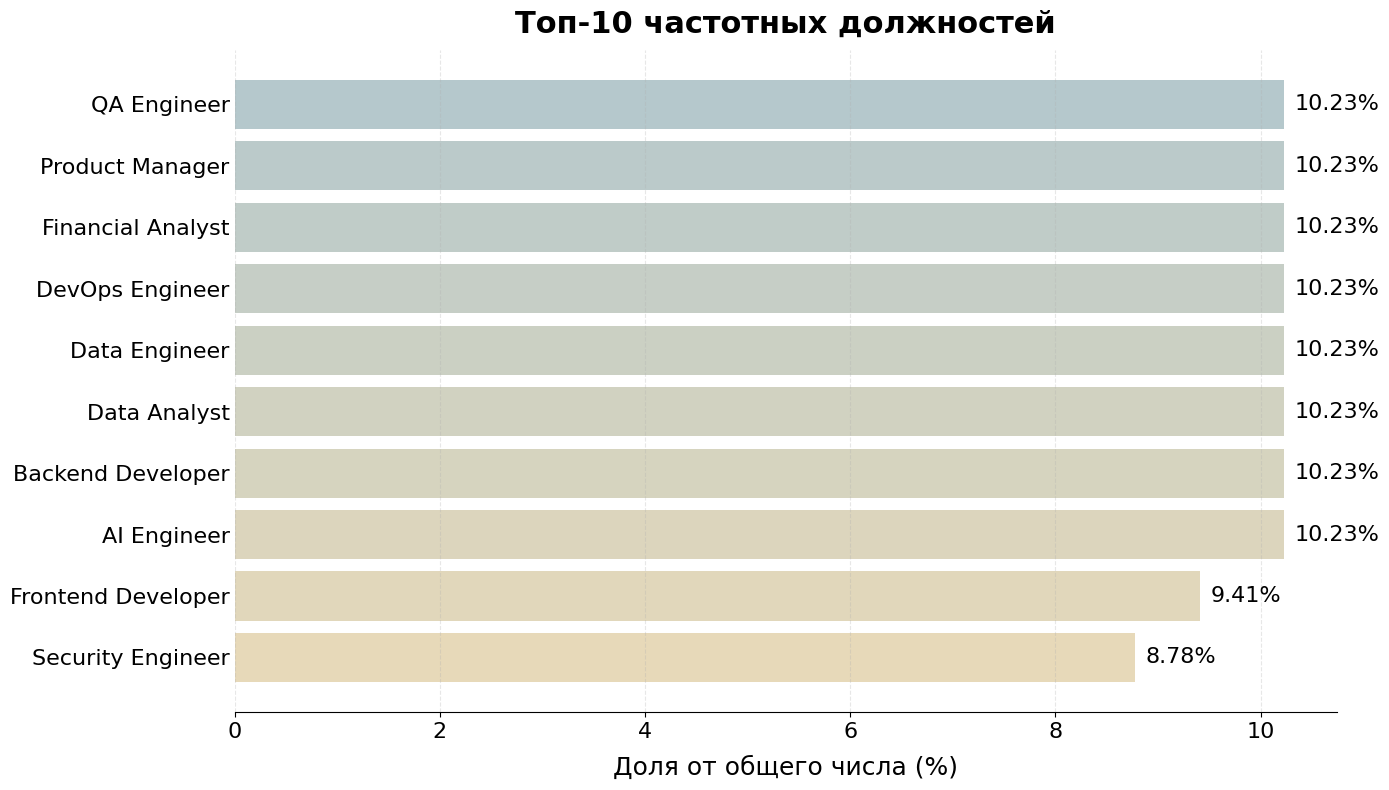

In [ ]:
top_n = 10
plot_top_with_percentage(
    series=samples_resume_balanced['title'],
    top_n=top_n,
    ylabel="",
    title=f"Топ-{top_n} частотных должностей",
)

In [25]:
# нормализуем навыки
samples_resume_balanced['clean_skills'] = samples_resume_balanced['clean_skills'].apply(str2list)
samples_resume_balanced["clean_skills"] = samples_resume_balanced["clean_skills"].apply(
    lambda x: tuple(sorted(x))
)

samples_resume_balanced["synth_skills_clean"] = samples_resume_balanced['clean_skills'].apply(clean_skill_list)
samples_resume_balanced["synth_skills_clean"] = samples_resume_balanced["clean_skills"].apply(normalize_sub_skills)
samples_resume_balanced["synth_skills_clean"] = samples_resume_balanced["clean_skills"].apply(remove_special_symp)

In [26]:
samples_resume_balanced['title'].value_counts()

title
AI Engineer           3000
Backend Developer     3000
Data Analyst          3000
Data Engineer         3000
DevOps Engineer       3000
Financial Analyst     3000
Product Manager       3000
QA Engineer           3000
Frontend Developer    2761
Security Engineer     2575
Name: count, dtype: int64

### Вакансия 

In [467]:
display(vacancy.head())
display(synth_vacancy.head())

,vacancy_id,name,area,published_at,salary_from,salary_to,currency,gross,experience_id,key_skills,...,url,lowe_case,lowe_case_str,title,responsibilities,requirements,skills,job_skills,clean_skills_tuple,job_skills_clean
0,130018647,Computer Vision Engineer,Москва,24.02.2026,100,100,100,100,between1And3,NaN,...,https://hh.ru/vacancy/130018647,милти тех – это инновационные решения для авто...,милти тех – это инновационные решения для авто...,Deep Learning Engineer,"Детектировать движущиеся (люди, машины, самока...",Твердая база знаний в области Computer Science...,"OpenCV, PyTorch, ROS","['OpenCV', 'PyTorch', 'ROS']","('OpenCV', 'PyTorch', 'ROS')","['opencv', 'ros', 'pytorch']"
1,130715005,Data Scientist (Computer Vision) — Middle-/Middle,Санкт-Петербург,24.02.2026,100,100,100,100,between1And3,"CV, Computer Vision",...,https://hh.ru/vacancy/130715005,we are looking for a middle-/middle data scien...,we are looking for a middle/middle data scient...,Deep Learning Engineer,"Разрабатывать, обучать и внедрять модели компь...",Степень бакалавра или магистра в области компь...,"Python NumPy, Pandas PyTorch ONNX / ONNX Runti...","['CV', 'Computer Vision']","('CV', 'Computer Vision')",['computer vision']
2,130458371,Ведущий инженер по техническому зрению (3D Vis...,Санкт-Петербург,16.02.2026,100,100,100,100,between1And3,NaN,...,https://hh.ru/vacancy/130458371,развитие промышленных решений в индутех компан...,развитие промышленных решений в индутех компан...,Deep Learning Engineer,Техническое сопровождение проектов: Экспертная...,Высшее или среднее профессиональное техническо...,C# и Python,['C# и Python'],"('C# и Python',)",['c и python']
3,130174355,Senior ML/DL Computer Vision engineer,Москва,04.02.2026,100,100,100,100,moreThan6,"C++, Python, PyTorch, Deep Learning, Computer ...",...,https://hh.ru/vacancy/130174355,evocargo создает транспорт будущего. мы проект...,evocargo создает транспорт будущего. мы проект...,Deep Learning Engineer,Разрабатывать и внедрять нейросетевые алгоритм...,Опыт решения прикладных задач от выявления про...,"Python, PyTorch, NumPy, OpenCV, scikit-learn, ...","['C++', 'Python', 'PyTorch', 'Deep Learning', ...","('C++', 'Computer Vision', 'Data Science', 'De...","['deep learning', 'data science', 'c', 'pytorc..."
4,129833507,Инженер машинного зрения (Senior computer vision),Йошкар-Ола,07.02.2026,100,100,100,100,between1And3,"C/C++, Python, OpenCV, Computer Vision",...,https://hh.ru/vacancy/129833507,обязательным условием является релокация в рес...,обязательным условием является релокация в рес...,Deep Learning Engineer,доработка существующих моделей: детектирование...,готовность к командировкам; знание и опыт рабо...,"Python, Tensorflow, PyTorch, OpenCV, NumPy, Ma...","['C/C++', 'Python', 'OpenCV', 'Computer Vision']","('C/C++', 'Computer Vision', 'OpenCV', 'Python')","['opencv', 'computer vision', 'python', 'c c']"


,resume_id,Должность,Описание,Навыки
0,131201008,Frontend Developer,"Разработка и поддержка frontend-компонентов, и...","React, Redux, TypeScript, GraphQL, SCSS/SASS, ..."
1,129725713,Frontend Developer,Разработка и оптимизация клиентской части веб-...,"Vue.js, Nuxt.js, TypeScript, Git, Docker, CMS ..."
2,129320450,Frontend Developer,Разработка и поддержка веб-приложений на Angul...,"Angular, React, Redux, Node.js, Express, REST ..."
3,130272401,Frontend Developer,Разработка высококачественных frontend-решений...,"Angular (включая версии 2 и выше), React, Redu..."
4,130849707,Frontend Developer,"Разработка и поддержка корпоративных сайтов, в...","Vue.js 2/3, Nuxt.js, TypeScript, GitLab, Docke..."


In [27]:
# избавимся от дубликатов со схожими 10 токенами

synth_vacancy.rename(
    columns={'resume_id':'vacancy_id'}, 
    inplace=True
)

synth_vacancy['prefix_10'] = synth_vacancy['Описание'].apply(get_prefix)
synth_vacancy = synth_vacancy.drop_duplicates(subset=["prefix_10"])
synth_vacancy.drop(columns=['prefix_10'], inplace=True)

In [28]:
samples_vacancy = synth_vacancy.merge(vacancy, on="vacancy_id", how="left")
samples_vacancy = samples_vacancy[['vacancy_id', 'title', 'Описание', 
                                   'responsibilities', 'requirements', 'Навыки', 
                                   'job_skills_clean']]

In [29]:
vacancy['Навыки'] = vacancy['job_skills_clean']
vacancy['Описание'] = vacancy['responsibilities'] + vacancy['requirements']
vacancy = vacancy[['vacancy_id', 'title', 'Описание', 
                                   'responsibilities', 'requirements', 'Навыки', 
                                   'job_skills_clean']]

In [30]:
# группируем df
# `Deep Learning Engineer` и `Artificial Intelligence Engineer` будем аггрегировать в категорию AI Engineer

mapping = {
    "Deep Learning Engineer": "AI Engineer",
    "Artificial Intelligence Engineer": "AI Engineer",
}

vacancy["title"] = vacancy["title"].replace(mapping)

In [31]:
vacancy.dropna(subset=['Описание'], inplace=True)

In [ ]:
# отберем по 2000 примеров для баланса

samples_vacancy_balanced = pd.concat([vacancy, samples_vacancy])
samples_vacancy_balanced = (
    samples_vacancy_balanced
    .groupby("title", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 2000), random_state=42))
    .reset_index(drop=True)
)

In [33]:
# переменнуем колонки + нормализуем навыки

samples_vacancy_balanced.rename(columns={'Описание':'description'}, inplace=True)

samples_vacancy_balanced['clean_skills'] = samples_vacancy_balanced['job_skills_clean'].apply(str2list)
samples_vacancy_balanced["clean_skills"] = samples_vacancy_balanced["clean_skills"].apply(
    lambda x: tuple(sorted(x))
)

samples_vacancy_balanced["clean_skills"] = samples_vacancy_balanced['clean_skills'].apply(clean_skill_list)
samples_vacancy_balanced["clean_skills"] = samples_vacancy_balanced["clean_skills"].apply(normalize_sub_skills)
samples_vacancy_balanced["clean_skills"] = samples_vacancy_balanced["clean_skills"].apply(remove_special_symp)

In [34]:
def title_to_tokens(title: str) -> set[str]:
    t = str(title).lower()
    t = re.sub(r"[|/,]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    tokens = [tok for tok in t.split(" ")]
    return set(tokens)

def compute_title_overlap(cv_title: str, job_title: str) -> int:
    return len(title_to_tokens(cv_title) & title_to_tokens(job_title))

def list_to_set(x):
    if isinstance(x, list):
        return set(s.lower() for s in x)
    return set()

def compute_skill_overlap(cv_set, job_set) -> int:
    return len(set(cv_set) & set(job_set))

In [ ]:
def build_cv_text(row) -> str:
    title = row.get("title", "").strip()
    description = row.get("description", "")
    skills = row.get("synth_skills_clean", "")
    skills = ", ".join(skills).strip()
    
    parts = []

    if title:
        parts.append(f"Должность: {title};")

    if description:
        parts.append(f"Описание: {description};")
    
    if skills:
        parts.append(f"Навыки: {skills}")

    return "\n".join(parts)



def build_job_text(row) -> str:
    title = row.get("title", "").strip()
    description = row.get("description", "")
    skills = row.get("clean_skills", "")
    skills = ", ".join(skills).strip()
    
    parts = []

    if title:
        parts.append(f"Должность: {title};")

    if description:
        parts.append(f"Описание: {description};")

    if skills:
        parts.append(f"Навыки: {skills}")

    return "\n".join(parts)

In [54]:
samples_resume_balanced["label_doc"] = samples_resume_balanced.apply(build_cv_text, axis=1)
samples_vacancy_balanced["label_doc"] = samples_vacancy_balanced.apply(build_job_text, axis=1)

samples_vacancy_balanced['label_doc'] = samples_vacancy_balanced['label_doc'].apply(lambda x: f'query: {x}') 
samples_resume_balanced['label_doc'] = samples_resume_balanced['label_doc'].apply(lambda x: f'passage: {x}') 

In [57]:
print(samples_resume_balanced.iloc[0]['label_doc'])

Должность: AI Engineer;
Описание: Участвовал в разработке и оптимизации RAG-пайплайнов для интеграции корпоративных данных, включая настройку векторных баз данных (Qdrant, Pinecone) для индексирования документов и реализацию гибридного поиска (dense + sparse embeddings). Разрабатывал REST/GraphQL API для ML-сервисов с использованием FastAPI и Pydantic, обеспечивая обработку ошибок, логирование и валидацию данных. Оптимизировал производительность систем, снижая latency и эффективно используя ресурсы. Участвовал в мониторинге качества моделей: сбор метрик, анализ ошибок, A/B-тестирование и улучшение генерации через оптимизацию системных промптов. Интегрировал LLM-сервисы с внешними API и корпоративными системами, применяя подходы prompt engineering и structured generation. Работал с embedding-моделями (Sentence Transformers, FastEmbed) и участвовал в fine-tuning моделей через HuggingFace Hub. Создавал техническую документацию, участвовал в code review и взаимодействовал с продуктовой ком

In [58]:
print(samples_vacancy_balanced.iloc[0]['label_doc'])

Должность: AI Engineer;
Описание: Проведение исследовательского анализа данных (EDA) для выявления ключевых метрик и закономерностей, построение моделей. Data-driven подход к разработке Разработка и внедрение AI-агентов на базе LLM (SOTA open-source решения), в т.ч участие в создании и развитии RAG-систем (Retrieval-Augmented Generation) Проектировать архитектуру приложений и пайплайнов обработки пользовательских запросов Работа с LLM: написание и оптимизация промптов (prompt engineering), управление взаимодействием с моделью Интеграция решений с корпоративными системами, обеспечение их взаимодействия Создание автономных бизнес-процессов в компанииОпыт работы с Python и библиотеками: pytorch, pandas, numpy, SQLAlchemy, Scikit-learn, Matplotlib/Seaborn Писать поддерживаемый, читаемый код; участвовать в ревью, обсуждениях и формировании технических подходов Практический опыт в NLP: векторизация текста, классификация запросов, построение RAG-систем, дообучение языковых моделей, эмбеддинго

In [59]:
samples_vacancy_balanced.shape, samples_resume_balanced.shape # ((2617, 12), (44631, 9))

((18109, 9), (29336, 7))

### Сформируем эмбединги для векторного приблежения

In [60]:
model = SentenceTransformer("intfloat/multilingual-e5-large",device='cuda')

No sentence-transformers model found with name BAAI/bge-reranker-large. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: BAAI/bge-reranker-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [61]:
samples_resume_balanced

,resume_id,description,title,string_experiences,clean_skills,synth_skills_clean,label_doc
0,3c4eda4100031554f80039ed1f7a417957446b,Участвовал в разработке и оптимизации RAG-пайп...,AI Engineer,Консультирование и настройка рабочей среды Sta...,"(python, искусственный интеллект, коммуникатив...","[python, искусственный интеллект, коммуникатив...",Должность: AI Engineer;\nОписание: Участвовал ...
1,6e82556200061083130039ed1f61356e774167,В рамках проектов по оптимизации производствен...,AI Engineer,Разработка стратегий открытия новых материалов...,"(data analysis, endnote, mathcad, matlab, ms e...","[data analysis, endnote, mathcad, matlab, ms e...",Должность: AI Engineer;\nОписание: В рамках пр...
2,6e82556200061083130039ed1f61356e774167,Участие в разработке программного обеспечения ...,AI Engineer,Разработка стратегий открытия новых материалов...,"(data analysis, endnote, mathcad, matlab, ms e...","[data analysis, endnote, mathcad, matlab, ms e...",Должность: AI Engineer;\nОписание: Участие в р...
3,09ff81050007df376e0039ed1f666535304c73,Обработал и проанализировал данные из различны...,AI Engineer,"Разработал систему прокторинга для кандидатов,...","(api, blockchain, bootstrap, express js, git, ...","[api, blockchain, bootstrap, express js, git, ...",Должность: AI Engineer;\nОписание: Обработал и...
4,e4acd0490008bb66480039ed1f48716d516e59,Участвовал в разработке ML-кода на Python с ис...,AI Engineer,Разработал пайплайны обучения и версионировани...,"(apache kafka, clearml, computer vision, conti...","[apache kafka, clearml, computer vision, conti...",Должность: AI Engineer;\nОписание: Участвовал ...
...,...,...,...,...,...,...,...
29331,0eab183b00033c29800039ed1f53324b6b346f,Участвовал в разработке и оптимизации методов ...,Security Engineer,"Администрирование инфраструктуры предприятия, ...","(active directory, dhcp, git, linux, ms sql se...","[active directory, dhcp, git, linux, ms sql se...",Должность: Security Engineer;\nОписание: Участ...
29332,92425b310000b55a1f0039ed1f736563726574,Настройка и сопровождение инфраструктуры прило...,Security Engineer,"Развертывание и сопровождение MDM-систем, инте...","(android, atlassian jira, bash, development op...","[android, atlassian jira, bash, development op...",Должность: Security Engineer;\nОписание: Настр...
29333,92425b310000b55a1f0039ed1f736563726574,Участвовал в внедрении и сопровождении MDM/MAM...,Security Engineer,"Развертывание и сопровождение MDM-систем, инте...","(android, atlassian jira, bash, development op...","[android, atlassian jira, bash, development op...",Должность: Security Engineer;\nОписание: Участ...
29334,9c0980b400006c5e990039ed1f736563726574,Обеспечивал бесперебойную работу ИТ-инфраструк...,Security Engineer,Обеспечение бесперебойной и безопасной работы ...,"(active directory, configuration manager, deve...","[active directory, configuration manager, deve...",Должность: Security Engineer;\nОписание: Обесп...


In [62]:
resume_doc_emb = model.encode(
    samples_resume_balanced['label_doc'].tolist(), batch_size=64, convert_to_tensor=True, show_progress_bar=True
)
vacancy_doc_emb = model.encode(
    samples_vacancy_balanced["label_doc"].tolist(), batch_size=64, convert_to_tensor=True, show_progress_bar=True
)

matrix_cos_sim = util.cos_sim(resume_doc_emb, vacancy_doc_emb)
matrix_cos_sim.shape

Batches:   0%|          | 0/459 [00:00<?, ?it/s]

Batches:   0%|          | 0/283 [00:00<?, ?it/s]

torch.Size([29336, 18109])

In [206]:
### Соберем датасет

TOP_K = 200
POS_MIN_TITLE_TOKENS = 1

MED_HARD_MIN_SIM = 0.4
MED_HARD_MAX_SIM = 0.89

MAX_POS_PER_JOB = 60
MAX_NEG_PER_JOB = 60

RANDOM_NEG_POOL = 500

pseudo_pairs = []

num_cvs = samples_resume_balanced.shape[0]
num_jobs = samples_vacancy_balanced.shape[0]

for j in tqdm(range(num_jobs), desc="Pseudo-labelling"):

    job_row = samples_vacancy_balanced.iloc[j]
    job_id = job_row["vacancy_id"]
    job_text = job_row["label_doc"]
    job_skills = job_row["clean_skills"]
    job_description = job_row["description"]
    job_title = job_row["title"]

    sims = matrix_cos_sim[:, j].cpu().numpy()
    top_k_idx = np.argsort(-sims)[:TOP_K]

    pos_count = 0
    neg_count = 0

    positive_candidates = []
    negative_candidates = []


    for i in top_k_idx:

        sim = sims[i] 
        cv_row = samples_resume_balanced.iloc[i]

        cv_id = cv_row["resume_id"]
        cv_text = cv_row["label_doc"]
        cv_skills = cv_row["clean_skills"]
        cv_description = cv_row["description"]
        cv_title = cv_row["title"]

        skill_overlap = compute_skill_overlap(cv_skills, job_skills)
        title_overlap = compute_title_overlap(cv_title, job_title)

        candidate = (
            job_id, cv_id,
            job_text, cv_text,
            job_title, cv_title,
            job_skills, cv_skills,
            job_description, cv_description
        )

        if title_overlap >= POS_MIN_TITLE_TOKENS and sim > 0.9:
            positive_candidates.append(candidate)
        
        elif title_overlap >= POS_MIN_TITLE_TOKENS and MED_HARD_MIN_SIM <= sim <= MED_HARD_MAX_SIM:
            negative_candidates.append(candidate)
        
        elif title_overlap == 0:
            negative_candidates.append(candidate)

    for c in positive_candidates[:MAX_POS_PER_JOB]:

        pseudo_pairs.append((*c, 1))
        pos_count += 1

    for c in negative_candidates[:MAX_NEG_PER_JOB]:

        pseudo_pairs.append((*c, 0))
        neg_count += 1

    if neg_count < MAX_NEG_PER_JOB:

        need_neg = MAX_NEG_PER_JOB - neg_count

        all_idx = np.arange(num_cvs)
        neg_pool = np.setdiff1d(all_idx, top_k_idx)

        if len(neg_pool) > 0:

            rand_idx = np.random.choice(
                neg_pool,
                size=min(RANDOM_NEG_POOL, len(neg_pool)),
                replace=False
            )

            for i in rand_idx:

                cv_row = samples_resume_balanced.iloc[i]

                cv_id = cv_row["resume_id"]
                cv_text = cv_row["label_doc"]
                cv_skills = cv_row["clean_skills"]
                cv_description = cv_row["description"]
                cv_title = cv_row["title"]

                skill_overlap = compute_skill_overlap(cv_skills, job_skills)
                title_overlap = compute_title_overlap(cv_title, job_title)

                if skill_overlap == 0 and title_overlap == 0:

                    pseudo_pairs.append(
                        (job_id, cv_id,
                         job_text, cv_text,
                         job_title, cv_title,
                         job_skills, cv_skills,
                         job_description, cv_description,
                         0)
                    )

                    neg_count += 1

                    if neg_count >= MAX_NEG_PER_JOB:
                        break

Pseudo-labelling: 100%|███████████████████| 18109/18109 [31:03<00:00,  9.72it/s]


In [207]:
pairs_df = pd.DataFrame(pseudo_pairs, columns=["query_id", "passage_id",
                                                "query", "passage",
                                                "query_category",  "passage_category",
                                                "query_skills", "passage_skills", 
                                                "query_description", "passage_description", 
                                                "label"])

In [208]:
# Избавимся от неточностей
pairs_balanced = pairs_df.copy()
mask = ((pairs_balanced["label"] == 1) & (pairs_balanced["passage_category"] != pairs_balanced["query_category"]))

print(f"Количество ошибочно положительных пар: {pairs_balanced[mask].shape[0]}")
pairs_balanced.loc[mask, "label"] = 0

Количество ошибочно положительных пар: 635433


In [209]:
pairs_balanced['query_category'].unique()

array(['AI Engineer', 'Backend Developer', 'Data Analyst',
       'Data Engineer', 'DevOps Engineer', 'Financial Analyst',
       'Frontend Developer', 'Product Manager', 'QA Engineer',
       'Security Engineer'], dtype=object)

### Разделим данные на train / valid / test

Будем выполнять стратифицированное разбиение по вакансиям.   
Для этого предварительно:   

1. считаем количество позитивных примеров для каждой вакансии;
2. разбиваем вакансии на бины по числу позитивов;
3. выполняем стратифицированный сплит на train, valid и test;
4. учитываем уникальность вакансий (query_id), чтобы избежать утечки данных между выборками.

In [181]:
def build_query(row):
    skills = ", ".join(row["query_skills"]) if isinstance(row["query_skills"], list) else ""
    
    return (
        f"Должность: {row['query_category']};\n"
        f"Описание: {row['query_description']};\n"
        f"Навыки: {skills}"
    )

def build_passage(row):
    skills = ", ".join(row["passage_skills"]) if isinstance(row["passage_skills"], list) or isinstance(row["passage_skills"], tuple) else ""
    
    return (
        f"Должность: {row['passage_category']};\n"
        f"Описание: {row['passage_description']};\n"
        f"Навыки: {skills}"
    )

pairs_balanced["query"] = pairs_balanced.apply(build_query, axis=1)
pairs_balanced["passage"] = pairs_balanced.apply(build_passage, axis=1)

### Сформируем query_id & passage_id

In [182]:
import hashlib
import os
import json
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm

def text_hash(text: str, prefix: str) -> str:
    h = hashlib.sha1(text.encode("utf-8")).hexdigest()
    return f"{prefix}_{h}"

In [183]:
pairs_balanced['query_id'] = pairs_balanced['query'].apply(lambda key: text_hash(key, 'q'))
pairs_balanced['passage_id'] = pairs_balanced['passage'].apply(lambda key: text_hash(key, 'd'))

In [184]:
# избавляемся от query которые не имеют положительных примеров
valider = (
    pairs_balanced.groupby("query_id")["label"]
    .sum()                     
    .loc[lambda x: x > 0]      
    .index
)

pairs_balanced = pairs_balanced[pairs_balanced["query_id"].isin(valider)].copy()

In [ ]:
# Точка сохранения
# pairs_balanced.to_json(
#     "pairs_balanced.jsonl",
#     orient="records",
#     lines=True,
#     force_ascii=False
# )

In [ ]:
pairs_balanced = pd.read_json(
    "pairs_balanced.jsonl",
    orient="records",
    lines=True
)
ex_resume_part1 = pd.read_json(
    "extract_resume_part1.jsonl",
    orient="records",
    lines=True
)
ex_resume_part2 = pd.read_json(
    "extract_resume_part2.jsonl",
    orient="records",
    lines=True
)

ex_vacancy_part2 = pd.read_json(
    "extract_vacancy_part1.jsonl",
    orient="records",
    lines=True
)

In [186]:
ex_resume = pd.concat([ex_resume_part1, ex_resume_part2])
ex_resume.head()

,passage_id,skills
0,d_2c5ee3d5b9954889d6df31d1dcff1e38bbcbf001,"Python, LLM, ML, OpenAI, prompt engineering, C..."
1,d_b692993f1ee2d2cbd0d07193a3368b6be16de0db,"Python, SQL, Pandas, NumPy, Docker, Git, Airfl..."
2,d_bf0b9b04a81f3b51ec4fd9a42a0f66f738017d5a,"анализ текущих финансовых показателей, 1С, Exc..."
3,d_a4453cb9f405c9ea9d67b17fe75cf41064e7929c,"agile project management, kanban, cross-functi..."
4,d_8c40a5aec252cae1edfff3b77e00f758be76a3e1,"A/B-тестирование, CustDev, GA4, Yandex Metrika..."


In [187]:
pairs_balanced = pairs_balanced[['query_id', 'passage_id', 
                                 'query', 'passage', 'query_category',
                                 'passage_category', 'passage_skills',
                                 'query_description', 'passage_description', 'label']] \
.merge(ex_vacancy_part2, on='query_id', how='left') \
.rename(columns={'skills':'query_skills'})

pairs_balanced = pairs_balanced[['query_id', 'passage_id', 'query', 'passage', 'query_category',
       'passage_category', 'query_skills',
       'query_description', 'passage_description', 'label']] \
.merge(ex_resume, on='passage_id', how='left') \
.rename(columns={'skills':'passage_skills'})

In [188]:
pairs_balanced = pairs_balanced[['query_id', 'passage_id', 
                                 'query', 'passage', 'query_category',
                                 'passage_category', 'query_skills', 'passage_skills',
                                 'query_description', 'passage_description', 'label']]

In [ ]:
pairs_balanced["query"] = pairs_balanced.apply(build_query, axis=1)
pairs_balanced["passage"] = pairs_balanced.apply(build_passage, axis=1)

pairs_balanced['query_skills'] = pairs_balanced['query_skills'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
pairs_balanced['passage_skills'] = pairs_balanced['passage_skills'].apply(lambda x: x.split(',') if isinstance(x, str) else x)

In [191]:
## добавим сжатые описания вакансий/резюме
resume_short_description = pd.read_json(
    "resume_short_description_part1.jsonl",
    orient="records",
    lines=True
)

vacancy_short_description = pd.read_json(
    "vacancy_short_description_part1.jsonl",
    orient="records",
    lines=True
)

In [ ]:
resume_short_description.rename(columns={'short_description':'passage_short_description'}, inplace=True)
vacancy_short_description.rename(columns={'short_description':'query_short_description'}, inplace=True)

pairs_balanced = pairs_balanced.merge(vacancy_short_description, on="query_id", how='left')
pairs_balanced = pairs_balanced.merge(resume_short_description, on="passage_id", how='left')

In [194]:
pairs_balanced = pairs_balanced[['query_id', 'passage_id', 'query', 'passage', 'query_category',
       'passage_category', 'query_skills', 'passage_skills',
       'query_description', 'passage_description', 'query_short_description', 'passage_short_description', 'label']]

In [ ]:
# Точка временного сохранения
# pairs_balanced.to_json(
#     "pairs_balanced_v3.jsonl",
#     orient="records",
#     lines=True,
#     force_ascii=False
# )

In [223]:
import pandas as pd
pairs_balanced = pd.read_json(
    "pairs_balanced_v3.jsonl",
    orient="records",
    lines=True
)

In [236]:
print(pairs_balanced.iloc[0]['query'])

Должность: AI Engineer;
Описание: Проведение исследовательского анализа данных (EDA) для выявления ключевых метрик и закономерностей, построение моделей. Data-driven подход к разработке Разработка и внедрение AI-агентов на базе LLM (SOTA open-source решения), в т.ч участие в создании и развитии RAG-систем (Retrieval-Augmented Generation) Проектировать архитектуру приложений и пайплайнов обработки пользовательских запросов Работа с LLM: написание и оптимизация промптов (prompt engineering), управление взаимодействием с моделью Интеграция решений с корпоративными системами, обеспечение их взаимодействия Создание автономных бизнес-процессов в компанииОпыт работы с Python и библиотеками: pytorch, pandas, numpy, SQLAlchemy, Scikit-learn, Matplotlib/Seaborn Писать поддерживаемый, читаемый код; участвовать в ревью, обсуждениях и формировании технических подходов Практический опыт в NLP: векторизация текста, классификация запросов, построение RAG-систем, дообучение языковых моделей, эмбеддинго

## Сформулируем корпус

In [ ]:
def build_corpus_queries_qrels(
    pairs_df: pd.DataFrame,
    test_size: float,
    seed: int,
    save_dir: str
):
    """
    Делает split по query_id.
    """

    os.makedirs(save_dir, exist_ok=True)
    train_dir = os.path.join(save_dir, "train")
    test_dir = os.path.join(save_dir, "test")
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    job_stats = (
        pairs_df
        .groupby("query_id")["label"]
        .agg(["sum", "count"])
        .reset_index()
    )

    job_stats["pos_count"] = job_stats["sum"]
    job_stats["pos_bin"] = pd.qcut(job_stats["pos_count"], q=4, duplicates="drop")


    train_jobs, test_jobs = train_test_split(
        job_stats["query_id"],
        test_size=test_size,
        random_state=seed,
        stratify=job_stats["pos_bin"]
    )

    train_df = pairs_df[pairs_df["query_id"].isin(train_jobs)].copy()
    test_df = pairs_df[pairs_df["query_id"].isin(test_jobs)].copy()


    def build_corpus(df, desc):
        corpus = {}
        for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
            pid = str(row["passage_id"])
            if pid not in corpus:
                passage_category = row["passage_category"]
                
                passage_skills = row["passage_skills"]
                passage_skills = ", ".join(passage_skills)
                
                passage_description = row["passage_description"]
                passage_short_description = row["passage_short_description"]
                passage_text = row["passage"]
                
                corpus[pid] = {
                    "title": str(passage_category) if pd.notna(passage_category) else "",
                    "text": str(passage_text) if pd.notna(passage_text) else "",
                    "skills": str(passage_skills) if pd.notna(passage_skills) else "",
                    "description": str(passage_description) if pd.notna(passage_description) else "",
                    "short_description": str(passage_short_description) if pd.notna(passage_short_description) else passage_description,
                }
                
        return corpus

    train_corpus = build_corpus(train_df, "Building train corpus")
    test_corpus = build_corpus(test_df, "Building test corpus")


    def build_queries(df, desc):
        queries = {}
        for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
            pid = str(row["query_id"])
            if pid not in queries:
                query_category = row["query_category"]
                
                query_skills = row["query_skills"]
                query_skills = ", ".join(query_skills)
                
                query_description = row["query_description"]
                query_short_description = row["query_short_description"]
                query_text = row["query"]
                
                queries[pid] = {
                    "title": str(query_category) if pd.notna(query_category) else "",
                    "text": str(query_text) if pd.notna(query_text) else "",
                    "skills": str(query_skills) if pd.notna(query_skills) else "",
                    "description": str(query_description) if pd.notna(query_description) else "",
                    "short_description": str(query_short_description) if pd.notna(query_short_description) else query_description,
                }
                
        return queries


    queries_train = build_queries(train_df, "Building train queries")
    queries_test = build_queries(test_df, "Building test queries")


    def build_qrels(df, desc):
        qrels = {}
        for qid, group in tqdm(
            df.groupby("query_id"),
            total=df["query_id"].nunique(),
            desc=desc
        ):
            qrels[str(qid)] = {
                str(r["passage_id"]): int(r["label"])
                for _, r in group.iterrows()
            }
        return qrels

    qrels_train = build_qrels(train_df, "Building train qrels")
    qrels_test = build_qrels(test_df, "Building test qrels")


    with open(os.path.join(train_dir, "corpus.json"), "w", encoding="utf-8") as f:
        json.dump(train_corpus, f, ensure_ascii=False)

    with open(os.path.join(train_dir, "queries.json"), "w", encoding="utf-8") as f:
        json.dump(queries_train, f, ensure_ascii=False)

    with open(os.path.join(train_dir, "qrels.json"), "w", encoding="utf-8") as f:
        json.dump(qrels_train, f, ensure_ascii=False)

    with open(os.path.join(test_dir, "corpus.json"), "w", encoding="utf-8") as f:
        json.dump(test_corpus, f, ensure_ascii=False)

    with open(os.path.join(test_dir, "queries.json"), "w", encoding="utf-8") as f:
        json.dump(queries_test, f, ensure_ascii=False)

    with open(os.path.join(test_dir, "qrels.json"), "w", encoding="utf-8") as f:
        json.dump(qrels_test, f, ensure_ascii=False)

    print(f"Saved train/test splits into {save_dir}")

    return (
        train_corpus,
        test_corpus,
        queries_train,
        queries_test,
        qrels_train,
        qrels_test,
    )

In [ ]:
# Сохраняем сформированный датасет
train_corpus, test_corpus, train_queries, test_queries, train_qrels, test_qrels = build_corpus_queries_qrels(
    pairs_balanced, 
    test_size=0.2,
    seed=42,
    save_dir="benchmarks/raw/hr/"    
)

print("Train Corpus passages:", len(train_corpus))
print("Test Corpus passages:", len(test_corpus))
print()
print("Train queries:", len(train_queries))
print("Test queries:", len(test_queries))
print()
print("Train qrels:", len(train_qrels))
print("Test qrels:", len(test_qrels))

Building test qrels: 100%|█████████████████| 2988/2988 [00:09<00:00, 308.66it/s]


Saved train/test splits into benchmarks/raw/hr/
Train Corpus passages: 29334
Test Corpus passages: 28870

Train queries: 11949
Test queries: 2988

Train qrels: 11949
Test qrels: 2988
